<div style="border: 2px solid #4CAF50; padding: 10px; border-radius: 8px; background-color: #e8f5e9; text-align: center;">
  <strong style="font-size: 32px;">REDES NEURONALES ARTIFICIALES - PERCEPTRÓN</strong>
</div>

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

# Propagación hacia adelante en un perceptrón

- Se muestra cómo una neurona procesa una entrada.
-  Recibe vectores `inputs` y `weights`, suma un sesgo (`bias`)
-  y aplica una función de activación:

###  Escalón (Step)
$$
y = 
  \begin{cases}
    1 & \text{si } z > 0,\\
    0 & \text{si } z \le 0
  \end{cases}
$$

###  sigmoide
$$
y = \frac{1}{1 + e^{-(\sum_i w_i x_i + b)}}
$$


In [2]:
# función de activación y clase Perceptron

def step_activation(z):
    return np.where(z > 0, 1, 0)


def sigmoide_activation(z):
    return 1.0 / (1.0 + math.exp(-z))


# Definición de la clase Neuron con método forward
class Perceptron:
    def __init__(self, weights, bias):
        self.weights = np.array(weights)
        self.bias = bias

    def forward_Sigmoide(self, inputs):
        """
        inputs: numpy array de tamaño n
        weights: numpy array de tamaño n
        bias: valor escalar

        1. Calcula suma ponderada + bias
        2. Aplica función sigmoide
        """
        z = np.sum(inputs * self.weights) + self.bias
        y = sigmoide_activation(z)
        return z, y

    def forward_Step(self, inputs):
        """
        inputs: array 1D
        weights: array 1D
        bias: escalar
        """
        z = np.dot(inputs, self.weights) + self.bias
        y = step_activation(z)
        return z, y


## Ejemplo práctico

In [3]:
# Ejemplo con datos
# Definición de pesos y bias
p = Perceptron(weights=[0.6, -0.4, 0.2], bias=-0.1)

# Entradas de prueba
X = np.array([
    [1, 1, 0],
    [0, 1, 1],
    [1, 0, 1],
    [0, 0, 1],
])

# Propagación hacia adelante
for x in X:
    z, y = p.forward_Step(x)
    print(f"Entrada {x} -> z = {z:.2f}, salida (escalón) y = {y}")


Entrada [1 1 0] -> z = 0.10, salida (escalón) y = 1
Entrada [0 1 1] -> z = -0.30, salida (escalón) y = 0
Entrada [1 0 1] -> z = 0.70, salida (escalón) y = 1
Entrada [0 0 1] -> z = 0.10, salida (escalón) y = 1


## Otro ejemplo función de activación sigmoide

Probemos la neurona:
- Pesos: [0.5, -0.2, 0.1]
- Bias: 0.4
- Entradas: [1.0, 2.0, 3.0]


In [4]:
# Ejemplo numérico
neuron = Perceptron(weights=[0.5, -0.2, 0.1], bias=0.4)
inputs = np.array([1.0, 2.0, 3.0])

output = neuron.forward_Sigmoide(inputs)
print("Salida del perceptrón:", output)


Salida del perceptrón: (0.8, 0.6899744811276125)


### Detalle del cálculo

1. **Suma ponderada + bias**  
   $$
   z = (1.0·0.5) + (2.0·(-0.2)) + (3.0·0.1) + 0.4 = 0.5 - 0.4 + 0.3 + 0.4 = 0.8
   $$

2. **Activación sigmoide**  
   $$
   y = \frac{1}{1 + e^{-0.8}} \approx 0.69
   $$


In [5]:
# Verificación del cálculo paso a paso
z = np.dot(inputs, neuron.weights) + neuron.bias
y = 1.0 / (1.0 + math.exp(-z))
print(f"z = {z:.4f}, sigmoide(z) = {y:.4f}")


z = 0.8000, sigmoide(z) = 0.6900


# Algoritmo de Aprendizaje del Perceptrón

Se entrenará un perceptrón con activación escalón y la regla de actualización:

$$
w_j \leftarrow w_j + \eta (y^{(i)} - \hat{y}^{(i)}) x_j^{(i)},\quad
b \leftarrow b + \eta (y^{(i)} - \hat{y}^{(i)})
$$


In [6]:
# Definición del perceptrón con aprendizaje
class Perceptron:
    def __init__(self, n_features, learning_rate=0.1, n_epochs=10):
        self.lr = learning_rate
        self.epochs = n_epochs
        # Inicialización: pesos pequeños y bias a cero
        self.weights = np.zeros(n_features)
        self.bias = 0.0

    def step(self, z):
        return 1 if z > 0 else 0

    def predict(self, x):
        return self.step(np.dot(x, self.weights) + self.bias)

    def fit(self, X, y):
        """
        X: array de entradas (muestras × n_features)
        y: etiquetas (0 o 1)
        """
        history = []
        for epoch in range(self.epochs):
            errors = 0
            for xi, target in zip(X, y):
                z = np.dot(xi, self.weights) + self.bias
                pred = self.step(z)
                error = target - pred
                if error != 0:
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error
                    errors += 1
            history.append(errors)
            print(f"Epoch {epoch+1}: errores = {errors}")
            if errors == 0:
                break
        return history


## Dataset de ejemplo: puerta AND

### Resultados del entrenamiento

- Mostrará el número de errores en cada época.
- Terminará si se clasifica todo correctamente (errores = 0).


In [7]:
# Datos de entrenamiento (AND)
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1])

p = Perceptron(n_features=2, learning_rate=0.1, n_epochs=20)
history = p.fit(X, y)


Epoch 1: errores = 1
Epoch 2: errores = 3
Epoch 3: errores = 3
Epoch 4: errores = 2
Epoch 5: errores = 1
Epoch 6: errores = 0


In [8]:
# Evaluación
print("Pesos finales:", p.weights, "Bias:", p.bias)
for xi, target in zip(X, y):
    pred = p.predict(xi)
    print(f"Entrada {xi} → pred = {pred}, etiqueta = {target}")


Pesos finales: [0.2 0.1] Bias: -0.2
Entrada [0 0] → pred = 0, etiqueta = 0
Entrada [0 1] → pred = 0, etiqueta = 0
Entrada [1 0] → pred = 0, etiqueta = 0
Entrada [1 1] → pred = 1, etiqueta = 1


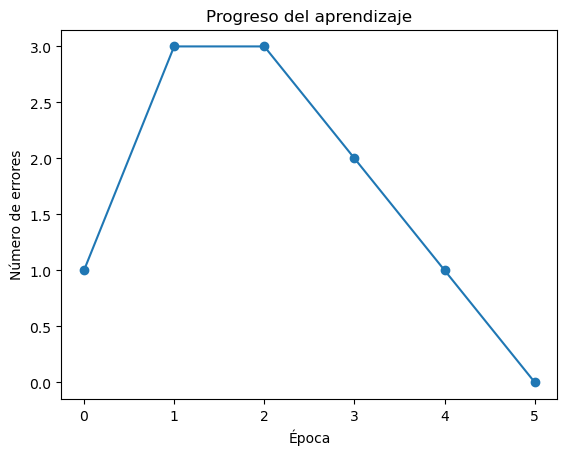

In [9]:
# visualizar errores por época

plt.plot(history, marker='o')
plt.xlabel('Época')
plt.ylabel('Número de errores')
plt.title('Progreso del aprendizaje')
plt.show()

---
---
# El Perceptrón como Clasificador
---
---

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_classification
import plotly.graph_objects as go

## Ejemplo 2D

Pesos aprendidos: [-0.16276642  0.46606745]
Sesgo aprendido: 0.1


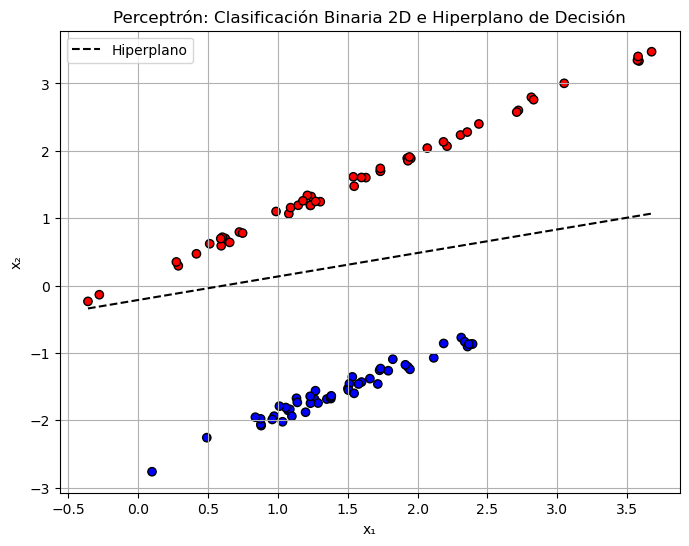

In [11]:
# Generar datos de ejemplo (2 clases, 2 características)
X, y = make_classification(
    n_samples=100, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_clusters_per_class=1,
    class_sep=1.5,
    random_state=42
)

# Convertir etiquetas a {0, 1} → {-1, 1} para el perceptrón
y = np.where(y == 0, -1, 1)

# Inicialización de pesos y sesgo
w = np.zeros(X.shape[1])
b = 0
eta = 0.1  # tasa de aprendizaje
n_epochs = 20

# Función de activación del perceptrón
def activation(z):
    return np.where(z >= 0, 1, -1)

# Entrenamiento
for epoch in range(n_epochs):
    for xi, target in zip(X, y):
        z = np.dot(xi, w) + b
        y_pred = activation(z)
        if y_pred != target:
            w += eta * target * xi
            b += eta * target

print(f'Pesos aprendidos: {w}')
print(f'Sesgo aprendido: {b}')

# Visualización del conjunto de datos y la frontera de decisión
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolors='k')

# Ecuación del hiperplano: w1*x + w2*y + b = 0  →  y = -(w1/w2)*x - b/w2
x_vals = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
if w[1] != 0:
    y_vals = -(w[0]/w[1])*x_vals - b/w[1]
    plt.plot(x_vals, y_vals, 'k--', label='Hiperplano')
else:
    plt.axvline(-b/w[0], color='k', linestyle='--', label='Hiperplano')

plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('Perceptrón: Clasificación Binaria 2D e Hiperplano de Decisión')
plt.legend()
plt.grid(True)
plt.show()

## Ejemplo 3D

In [12]:
# Datos 3D
X, y = make_classification(
    n_samples=100,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=2.0,
    random_state=0
)

y_bin = np.where(y == 0, -1, 1)

# Entrenamiento Perceptrón
w = np.zeros(3)
b = 0
eta = 0.1
for _ in range(20):
    for xi, target in zip(X, y_bin):
        pred = 1 if np.dot(w, xi) + b >= 0 else -1
        if pred != target:
            w += eta * target * xi
            b += eta * target

print('Pesos aprendidos:',w)
print('Sesgo aprendido:',b)


Pesos aprendidos: [ 0.04538103  0.03481265 -0.25320709]
Sesgo aprendido: 0.0


### Visualización

In [13]:
# Crear plano de decisión
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 10),
    np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 10)
)
zz = (-w[0]*xx - w[1]*yy - b) / w[2]

# Crear figura interactiva
fig = go.Figure()

# Puntos clase -1
fig.add_trace(go.Scatter3d(
    x=X[y==0][:,0], y=X[y==0][:,1], z=X[y==0][:,2],
    mode='markers',
    marker=dict(size=5, color='red'),
    name='Clase -1'
))

# Puntos clase +1
fig.add_trace(go.Scatter3d(
    x=X[y==1][:,0], y=X[y==1][:,1], z=X[y==1][:,2],
    mode='markers',
    marker=dict(size=5, color='blue'),
    name='Clase +1'
))

# Plano
fig.add_trace(go.Surface(
    x=xx, y=yy, z=zz,
    opacity=0.4,
    colorscale='Greens',
    showscale=False,
    name='Plano de decisión'
))

# Layout
fig.update_layout(
    scene=dict(
        xaxis_title='x₁',
        yaxis_title='x₂',
        zaxis_title='x₃'
    ),
    title='Perceptrón: Clasificación Binaria 3D e Hiperplano de Decisión',
    width=800,
    height=700
)

fig.show()

# Código que:

- Entrena un perceptrón sobre datos linealmente separables.
- Utiliza la función de costo Hinge (también conocida como SVM loss).
- Muestra la evolución del hiperplano de decisión.
- Ilustra gráficamente la regla de actualización en base al gradiente de la Hinge loss.

In [14]:
import numpy as np
import matplotlib.pyplot as plt

Número total de iteraciones hasta convergencia: 140
Pesos seleccionados para visualización (10 pasos espaciados):
Iteración 0: w = [0.5, -0.5, 0.9]
Iteración 15: w = [ 0.90760462 -0.03818121  0.85      ]
Iteración 31: w = [1.1058771  0.22381587 0.7       ]
Iteración 46: w = [1.1058771  0.22381587 0.7       ]
Iteración 62: w = [1.14033129 0.2839129  0.65      ]
Iteración 77: w = [1.17478549 0.34400992 0.6       ]
Iteración 93: w = [1.20923968 0.40410694 0.55      ]
Iteración 108: w = [1.20923968 0.40410694 0.55      ]
Iteración 124: w = [1.24369388 0.46420397 0.5       ]
Iteración 140: w = [1.27814807 0.52430099 0.45      ]


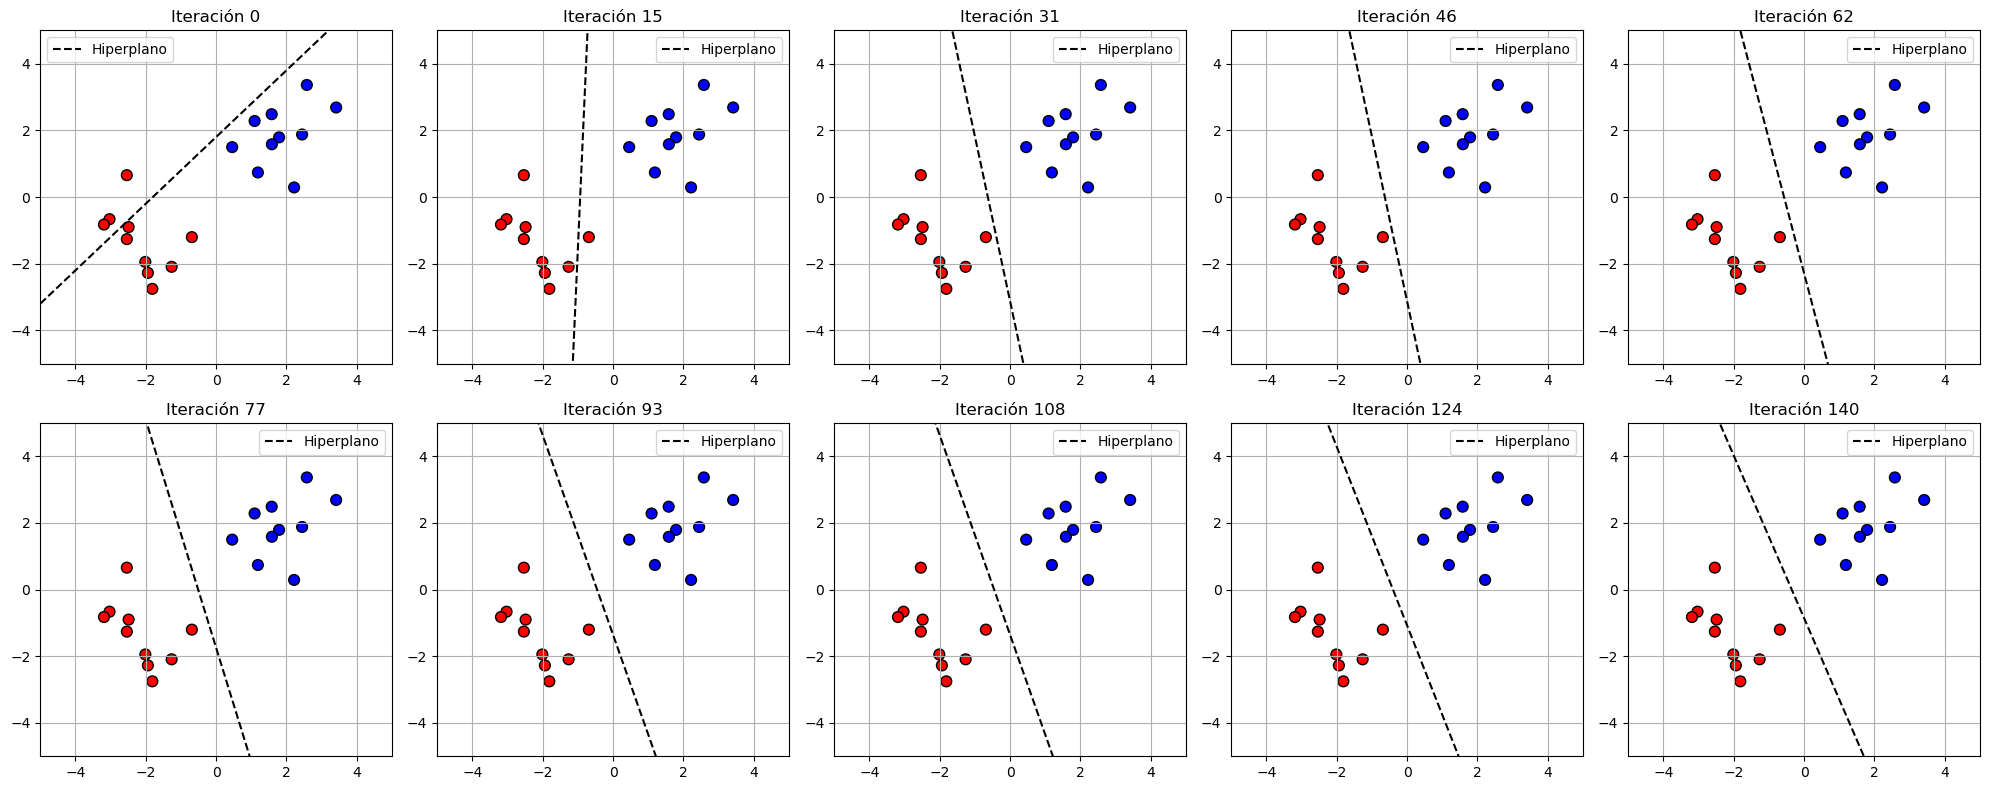

In [15]:

np.random.seed(42)

# Datos 2D con solapamiento para más iteraciones
X_pos = np.random.multivariate_normal([2, 2], [[0.8, 0], [0, 0.8]], 10)
X_neg = np.random.multivariate_normal([-2, -1], [[0.8, 0], [0, 0.8]], 10)
X = np.vstack([X_pos, X_neg])
y = np.array([1]*10 + [-1]*10)

# Añadir término bias
X_aug = np.hstack((X, np.ones((X.shape[0], 1))))

# Inicialización
#w = np.random.randn(3)
w = [ 0.73846658,  0.17136828, -0.11564828]
w = [ 0.17136828,  0.73846658, 0.91564828]
w = [ 0.5, -0.5, 0.9]

eta = 0.05
max_iters = 500  # límite máximo para evitar bucle infinito

history = [w.copy()]
iteration_count = 0
converged = False

# Gradiente subdiferencial hinge
def hinge_gradient(w, x, y):
    if y * np.dot(w, x) >= 1:
        return np.zeros_like(w)
    else:
        return -y * x

# Entrenamiento hasta convergencia
for epoch in range(max_iters):
    errors = 0
    for i in range(len(X)):
        grad = hinge_gradient(w, X_aug[i], y[i])
        if not np.allclose(grad, 0):
            errors += 1
        w -= eta * grad
        history.append(w.copy())
        iteration_count += 1

    # Criterio de convergencia: todos clasificados correctamente
    margins = y * (X_aug @ w)
    if np.all(margins >= 1):
        converged = True
        break

# Imprimir resultados
print("Número total de iteraciones hasta convergencia:", iteration_count)
print("Pesos seleccionados para visualización (10 pasos espaciados):")

# Seleccionar 10 iteraciones equidistantes
indices = np.linspace(0, len(history)-1, 10, dtype=int)

for idx in indices:
    print(f"Iteración {idx}: w = {history[idx]}")

# Visualización
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
x_vals = np.linspace(-5, 5, 100)
colors = ['blue' if label == 1 else 'red' for label in y]

for i, idx in enumerate(indices):
    ax = axes[i]
    w = history[idx]
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_title(f'Iteración {idx}')
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=60, edgecolors='k')

    if w[1] != 0:
        y_vals = -(w[0]*x_vals + w[2]) / w[1]
        ax.plot(x_vals, y_vals, 'k--', label='Hiperplano')
    else:
        ax.axvline(-w[2]/w[0], color='k', linestyle='--', label='Hiperplano')
    
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


# Log-loss (Binary Cross-Entropy) para clasificación binaria

- El código utiliza el gradiente de la log-loss con activación sigmoide.
- Las etiquetas se transforman a {0,1} como requiere la función log-loss.
- La condición de parada es cuando el gradiente promedio es pequeño (tolerance).
- Se grafican 10 iteraciones equidistantes entre el inicio y el final del entrenamiento.

Número total de iteraciones hasta convergencia: 400
Pesos seleccionados para visualización (10 pasos espaciados):
Iteración 0: w = [ 0.5 -0.5  0.9]
Iteración 44: w = [1.20665125 0.19328021 0.79349105]
Iteración 88: w = [1.41839242 0.41441029 0.74102139]
Iteración 133: w = [1.56034514 0.56607453 0.68881904]
Iteración 177: w = [1.65678216 0.65703811 0.65778834]
Iteración 222: w = [1.72844307 0.73528193 0.63461592]
Iteración 266: w = [1.78523084 0.79617468 0.61928545]
Iteración 311: w = [1.84297337 0.86396591 0.60293228]
Iteración 355: w = [1.88692701 0.9096146  0.58976093]
Iteración 400: w = [1.92942662 0.95190097 0.57631632]


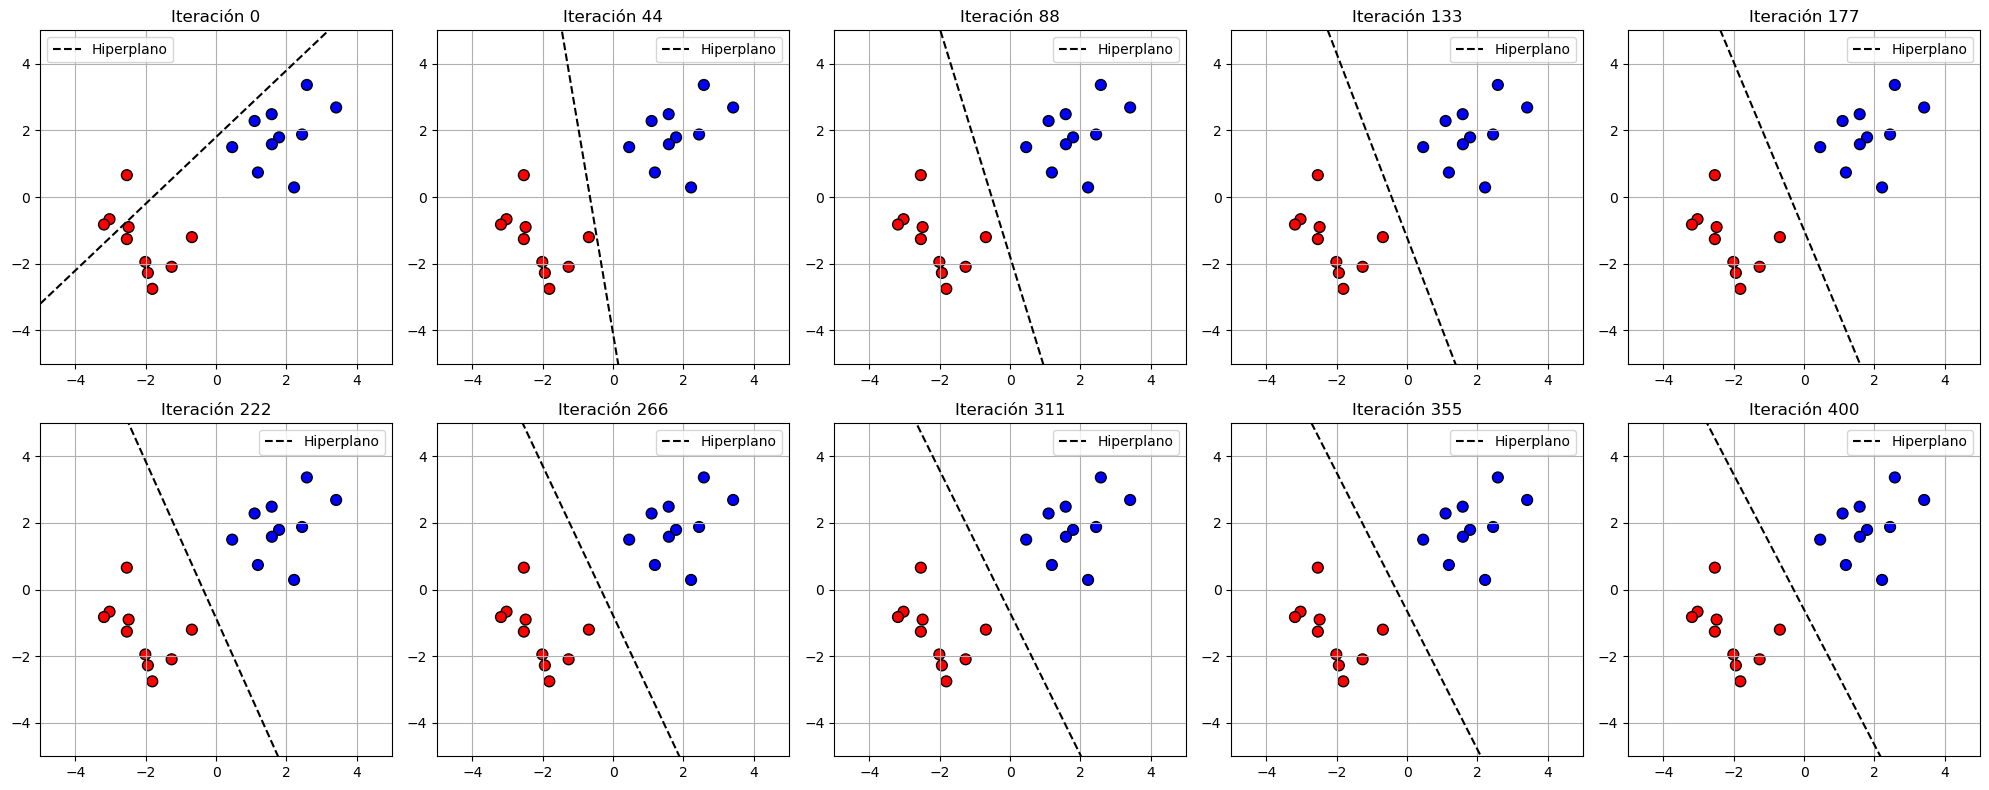

In [16]:

np.random.seed(42)

# Datos 2D con solapamiento para más iteraciones
X_pos = np.random.multivariate_normal([2, 2], [[0.8, 0], [0, 0.8]], 10)
X_neg = np.random.multivariate_normal([-2, -1], [[0.8, 0], [0, 0.8]], 10)
X = np.vstack([X_pos, X_neg])
y = np.array([1]*10 + [-1]*10)  # etiquetas {-1, 1}

# Etiquetas en {0,1} para log-loss
y_bin = (y + 1) // 2

# Añadir término bias
X_aug = np.hstack((X, np.ones((X.shape[0], 1))))

# Inicialización
w = np.array([0.5, -0.5, 0.9], dtype=float)

eta = 0.05
max_iters = 20
tolerance = 1e-4

history = [w.copy()]
iteration_count = 0

# Función sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Gradiente de log-loss
def log_loss_gradient(w, x, y_true):
    z = np.dot(w, x)
    y_pred = sigmoid(z)
    return (y_pred - y_true) * x

# Entrenamiento
for epoch in range(max_iters):
    grad_total = np.zeros_like(w)
    for i in range(len(X)):
        grad = log_loss_gradient(w, X_aug[i], y_bin[i])
        grad_total += grad
        w -= eta * grad
        history.append(w.copy())
        iteration_count += 1
    
    grad_norm = np.linalg.norm(grad_total / len(X))
    if grad_norm < tolerance:
        break

# Resultados
print("Número total de iteraciones hasta convergencia:", iteration_count)
print("Pesos seleccionados para visualización (10 pasos espaciados):")

indices = np.linspace(0, len(history)-1, 10, dtype=int)
for idx in indices:
    print(f"Iteración {idx}: w = {history[idx]}")

# Visualización
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
x_vals = np.linspace(-5, 5, 100)
colors = ['blue' if label == 1 else 'red' for label in y]

for i, idx in enumerate(indices):
    ax = axes[i]
    w_i = history[idx]
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_title(f'Iteración {idx}')
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=60, edgecolors='k')

    if w_i[1] != 0:
        y_vals = -(w_i[0]*x_vals + w_i[2]) / w_i[1]
        ax.plot(x_vals, y_vals, 'k--', label='Hiperplano')
    else:
        ax.axvline(-w_i[2]/w_i[0], color='k', linestyle='--', label='Hiperplano')
    
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


# Perceptrón con función de pérdida Log-loss y función de regularización L2 (también conocida como *ridge regularization*). 

- La pérdida total ahora será:

$$
\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{log}} + \frac{\lambda}{2} \|\mathbf{w}\|^2
$$

- Y el gradiente será:

$$
\nabla_{\mathbf{w}} \mathcal{L}_{\text{total}} = (\hat{y} - y) \cdot \mathbf{x} + \lambda \mathbf{w}
$$


Número total de iteraciones hasta convergencia: 400
Pesos seleccionados para visualización (10 pasos espaciados):
Iteración 0: w = [ 0.5 -0.5  0.9]
Iteración 44: w = [1.18906296 0.19600538 0.77507034]
Iteración 88: w = [1.37913949 0.41507369 0.70750352]
Iteración 133: w = [1.49763845 0.56241387 0.64106063]
Iteración 177: w = [1.57126826 0.64729911 0.59626684]
Iteración 222: w = [1.6181331  0.71871679 0.56017948]
Iteración 266: w = [1.65059217 0.77223867 0.53362867]
Iteración 311: w = [1.68434654 0.83329475 0.50734081]
Iteración 355: w = [1.7046937  0.87058656 0.48334137]
Iteración 400: w = [1.72397924 0.90386647 0.45874907]


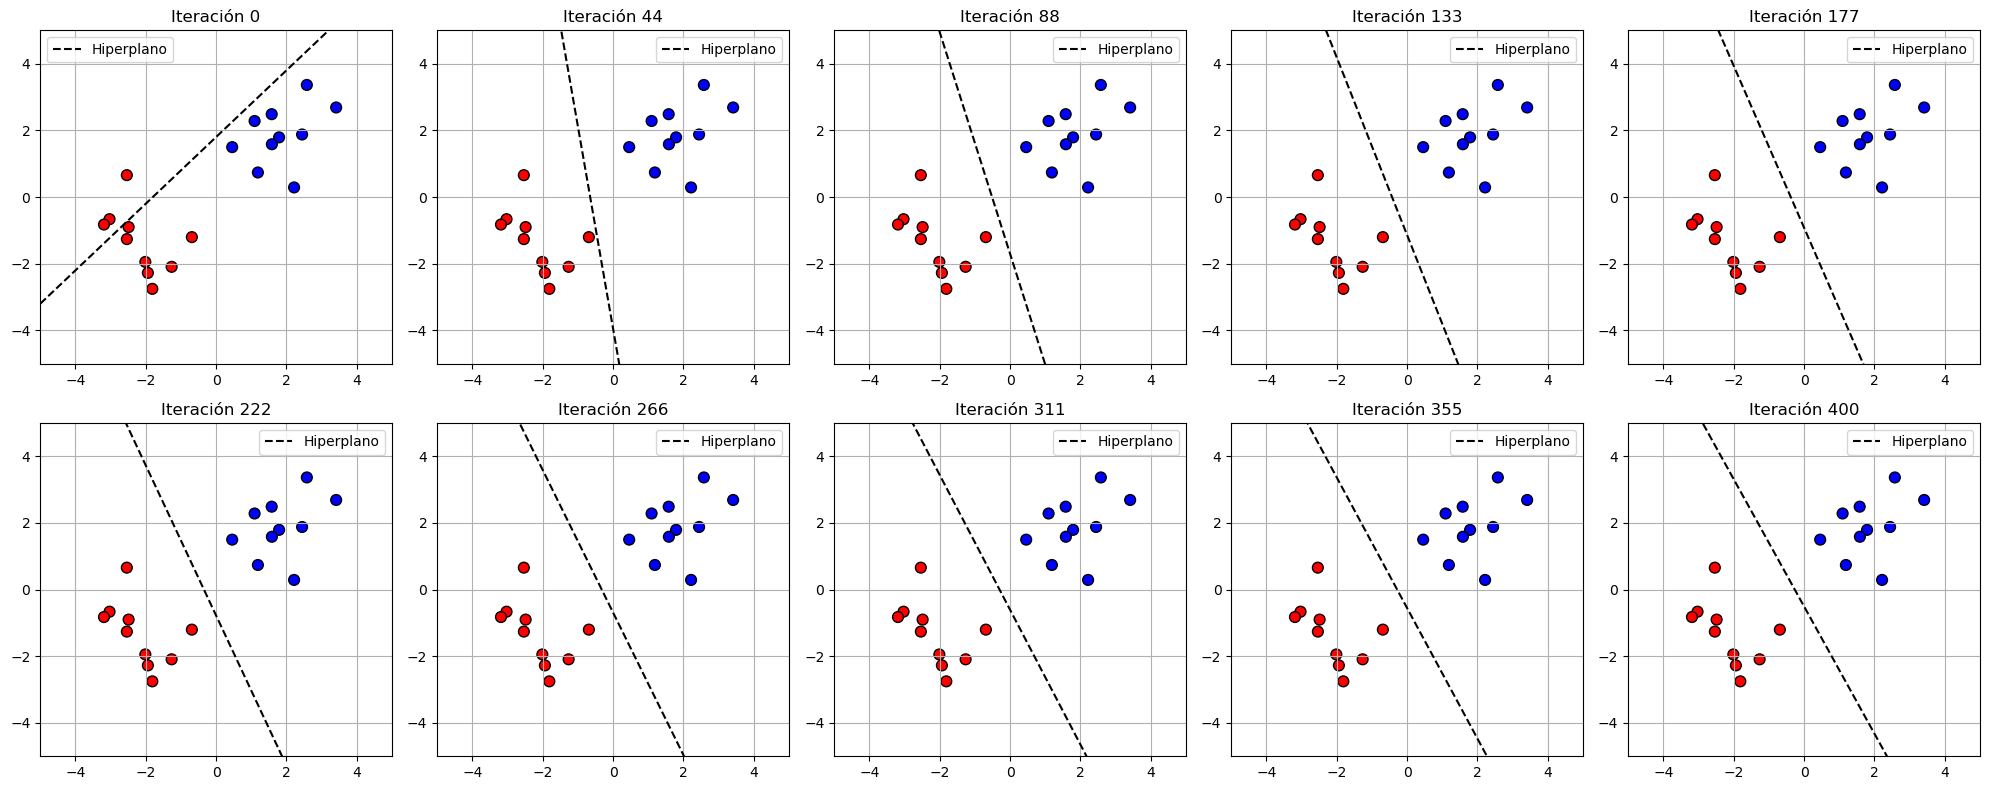

In [17]:
np.random.seed(42)

# Datos 2D con solapamiento para más iteraciones
X_pos = np.random.multivariate_normal([2, 2], [[0.8, 0], [0, 0.8]], 10)
X_neg = np.random.multivariate_normal([-2, -1], [[0.8, 0], [0, 0.8]], 10)
X = np.vstack([X_pos, X_neg])
y = np.array([1]*10 + [-1]*10)  # etiquetas {-1, 1}
y_bin = (y + 1) // 2  # etiquetas {0,1} para log-loss

# Añadir término bias
X_aug = np.hstack((X, np.ones((X.shape[0], 1))))

# Inicialización de pesos
w = np.array([0.5, -0.5, 0.9], dtype=float)

# Hiperparámetros
eta = 0.05
max_iters = 20
tolerance = 1e-4
lambda_reg = 0.01  # coeficiente de regularización L2

history = [w.copy()]
iteration_count = 0

# Función sigmoide
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Gradiente con regularización L2
def log_loss_grad_l2(w, x, y_true, lambda_reg):
    z = np.dot(w, x)
    y_pred = sigmoid(z)
    grad_log_loss = (y_pred - y_true) * x
    grad_reg = lambda_reg * w
    return grad_log_loss + grad_reg

# Entrenamiento
for epoch in range(max_iters):
    grad_total = np.zeros_like(w)
    for i in range(len(X)):
        grad = log_loss_grad_l2(w, X_aug[i], y_bin[i], lambda_reg)
        grad_total += grad
        w -= eta * grad
        history.append(w.copy())
        iteration_count += 1
    
    if np.linalg.norm(grad_total / len(X)) < tolerance:
        break

# Resultados
print("Número total de iteraciones hasta convergencia:", iteration_count)
print("Pesos seleccionados para visualización (10 pasos espaciados):")

indices = np.linspace(0, len(history)-1, 10, dtype=int)
for idx in indices:
    print(f"Iteración {idx}: w = {history[idx]}")

# Visualización
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
x_vals = np.linspace(-5, 5, 100)
colors = ['blue' if label == 1 else 'red' for label in y]

for i, idx in enumerate(indices):
    ax = axes[i]
    w_i = history[idx]
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_title(f'Iteración {idx}')
    ax.scatter(X[:, 0], X[:, 1], c=colors, s=60, edgecolors='k')

    if w_i[1] != 0:
        y_vals = -(w_i[0]*x_vals + w_i[2]) / w_i[1]
        ax.plot(x_vals, y_vals, 'k--', label='Hiperplano')
    else:
        ax.axvline(-w_i[2]/w_i[0], color='k', linestyle='--', label='Hiperplano')
    
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


---
# FUNCIONES DE ACTIVACIÓN
---

# Función de Activación: Lineal

La función **lineal** es la forma más simple de activación, donde la salida es directamente proporcional a la entrada. No introduce no linealidades, por lo que raramente se utiliza en capas ocultas, pero puede emplearse en la capa de salida de modelos de regresión.

## Definición

$$
f(z) = z
$$

La derivada de la función lineal es constante:

$$
f'(z) = 1
$$


In [18]:
# Importación de librerías
import numpy as np
import matplotlib.pyplot as plt


In [19]:
# Definición de la función lineal y su derivada
def linear(z):
    return z

def linear_derivative(z):
    return np.ones_like(z)


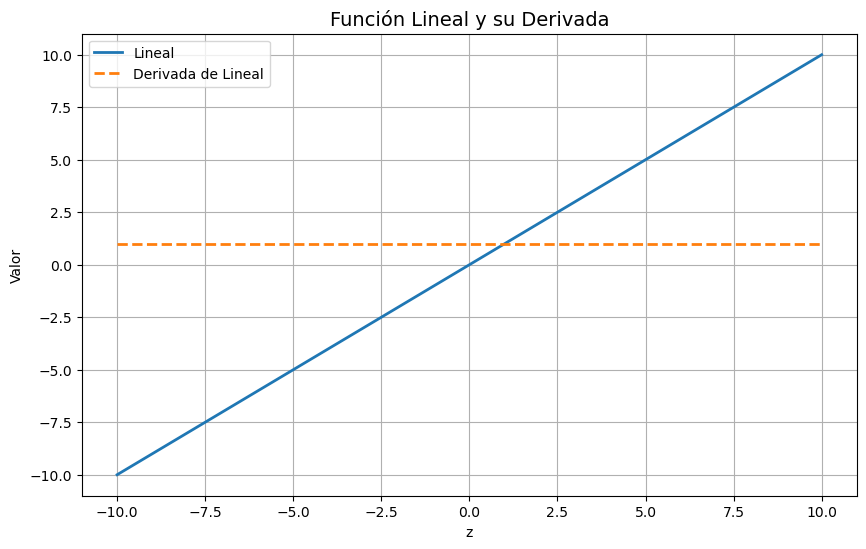

In [20]:
# Visualización de la función lineal y su derivada
z = np.linspace(-10, 10, 200)
l = linear(z)
dl = linear_derivative(z)

plt.figure(figsize=(10, 6))
plt.plot(z, l, label='Lineal', linewidth=2)
plt.plot(z, dl, label='Derivada de Lineal', linestyle='--', linewidth=2)
plt.title("Función Lineal y su Derivada", fontsize=14)
plt.xlabel("z")
plt.ylabel("Valor")
plt.grid(True)
plt.legend()
plt.show()


# Función de Activación: Sigmoid

La función **sigmoid** es una función de activación ampliamente utilizada en redes neuronales. Convierte cualquier valor real en el intervalo $(0, 1)$.

## Definición

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

La derivada de la función sigmoid es:

$$
\sigma'(z) = \sigma(z)(1 - \sigma(z))
$$


In [21]:
# Definición de la función sigmoid y su derivada
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)


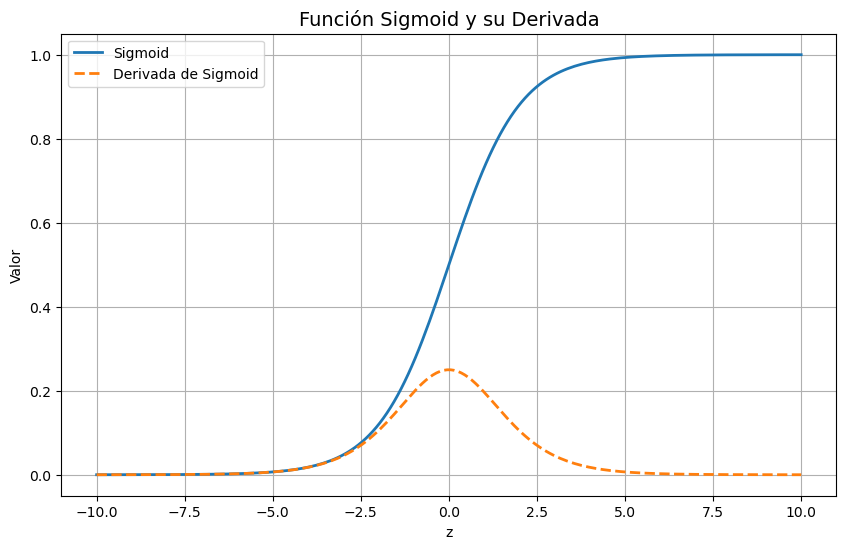

In [22]:
# Visualización
z = np.linspace(-10, 10, 200)
s = sigmoid(z)
ds = sigmoid_derivative(z)

plt.figure(figsize=(10, 6))
plt.plot(z, s, label='Sigmoid', linewidth=2)
plt.plot(z, ds, label="Derivada de Sigmoid", linestyle='--', linewidth=2)
plt.title("Función Sigmoid y su Derivada", fontsize=14)
plt.xlabel("z")
plt.ylabel("Valor")
plt.grid(True)
plt.legend()
plt.show()


# Función de Activación: Tanh

La función **tangente hiperbólica** (tanh) es otra función de activación muy utilizada, especialmente en redes neuronales antes del auge de ReLU. A diferencia de la sigmoid, su rango de salida es $(-1, 1)$, lo cual puede ayudar a centrar los datos alrededor de cero.

## Definición

$$
\tanh(z) = \frac{e^{z} - e^{-z}}{e^{z} + e^{-z}}
$$

La derivada de tanh es:

$$
\tanh'(z) = 1 - \tanh^2(z)
$$


In [23]:
# Definición de la función tanh y su derivada
def tanh(z):
    return np.tanh(z)

def tanh_derivative(z):
    return 1 - np.tanh(z)**2


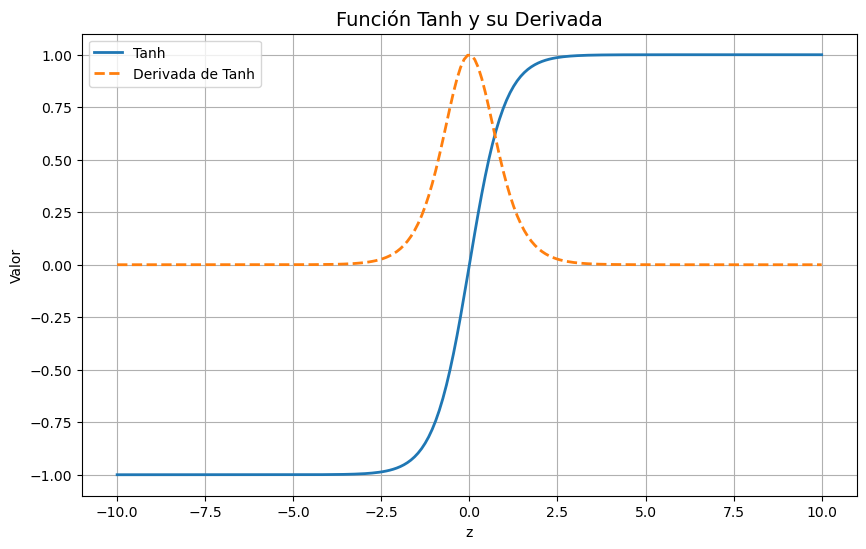

In [24]:
# Visualización
z = np.linspace(-10, 10, 200)
t = tanh(z)
dt = tanh_derivative(z)

plt.figure(figsize=(10, 6))
plt.plot(z, t, label='Tanh', linewidth=2)
plt.plot(z, dt, label="Derivada de Tanh", linestyle='--', linewidth=2)
plt.title("Función Tanh y su Derivada", fontsize=14)
plt.xlabel("z")
plt.ylabel("Valor")
plt.grid(True)
plt.legend()
plt.show()


# Función de Activación: ReLU

La función **ReLU** (Rectified Linear Unit) es actualmente una de las funciones de activación más utilizadas en redes neuronales profundas debido a su simplicidad y eficiencia computacional.

## Definición

$$
\text{ReLU}(z) = \max(0, z)
$$

La derivada de ReLU es:

$$
\text{ReLU}'(z) =
\begin{cases}
1 & \text{si } z > 0 \\
0 & \text{si } z \leq 0
\end{cases}
$$


In [25]:
# Definición de la función ReLU y su derivada
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return np.where(z > 0, 1.0, 0.0)


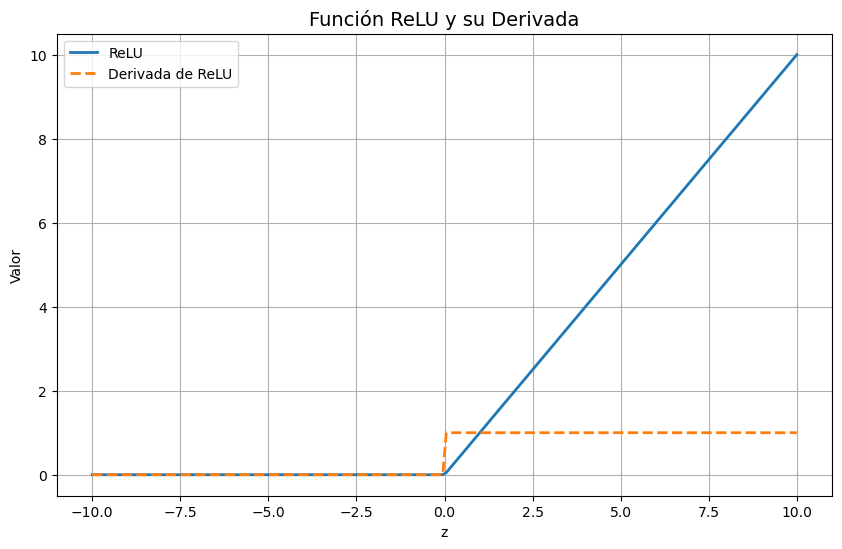

In [26]:
# Visualización
z = np.linspace(-10, 10, 200)
r = relu(z)
dr = relu_derivative(z)

plt.figure(figsize=(10, 6))
plt.plot(z, r, label='ReLU', linewidth=2)
plt.plot(z, dr, label="Derivada de ReLU", linestyle='--', linewidth=2)
plt.title("Función ReLU y su Derivada", fontsize=14)
plt.xlabel("z")
plt.ylabel("Valor")
plt.grid(True)
plt.legend()
plt.show()


# Función de Activación: Leaky ReLU

La **Leaky ReLU** es una variante de la función ReLU que permite un pequeño gradiente cuando la entrada es negativa. Esto ayuda a evitar el problema de ``neurona muerta'' que ocurre en ReLU.

## Definición

$$
\text{LeakyReLU}(z) =
\begin{cases}
z & \text{si } z > 0 \\
\alpha z & \text{si } z \leq 0
\end{cases}
$$

Donde $\alpha$ es un pequeño valor positivo, típicamente $\alpha = 0.01$.

La derivada de Leaky ReLU es:

$$
\text{LeakyReLU}'(z) =
\begin{cases}
1 & \text{si } z > 0 \\
\alpha & \text{si } z \leq 0
\end{cases}
$$


In [27]:
# Definición de la función Leaky ReLU y su derivada
def leaky_relu(z, alpha=0.01):
    return np.where(z > 0, z, alpha * z)

def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1.0, alpha)


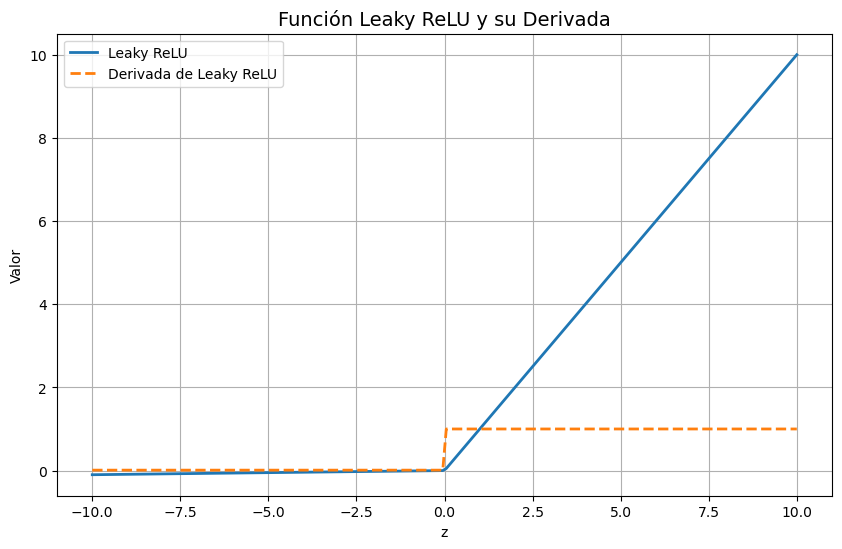

In [28]:
# Visualización
z = np.linspace(-10, 10, 200)
alpha = 0.01
lrelu = leaky_relu(z, alpha)
dlrelu = leaky_relu_derivative(z, alpha)

plt.figure(figsize=(10, 6))
plt.plot(z, lrelu, label='Leaky ReLU', linewidth=2)
plt.plot(z, dlrelu, label='Derivada de Leaky ReLU', linestyle='--', linewidth=2)
plt.title("Función Leaky ReLU y su Derivada", fontsize=14)
plt.xlabel("z")
plt.ylabel("Valor")
plt.grid(True)
plt.legend()
plt.show()


### Función de Activación: SELU (Scaled Exponential Linear Unit)

La función SELU fue diseñada para redes neuronales profundas que se auto-normalizan, manteniendo la media y varianza de las activaciones cerca de 0 y 1, respectivamente, durante el entrenamiento.

$$
\text{SELU}(x) = \lambda \begin{cases}
x & \text{si } x > 0 \\
\alpha (e^x - 1) & \text{si } x \leq 0
\end{cases}
$$

donde los parámetros son:

- $\lambda \approx 1.0507$
- $\alpha \approx 1.6733$

**Propiedades:**

- Mantiene las activaciones normalizadas automáticamente (self-normalizing).
- Elimina la necesidad de usar Batch Normalization.
- Requiere:
  - Inicialización **LeCun normal**.
  - Uso de **AlphaDropout** en lugar de Dropout tradicional.
  - Arquitecturas densamente conectadas.

**Comparación:**

A diferencia de ReLU o Leaky ReLU, SELU asegura que incluso las neuronas con activaciones pequeñas o negativas contribuyan al aprendizaje, y que toda la red mantenga un flujo de datos estable.

> SELU es útil especialmente en redes profundas completamente conectadas.


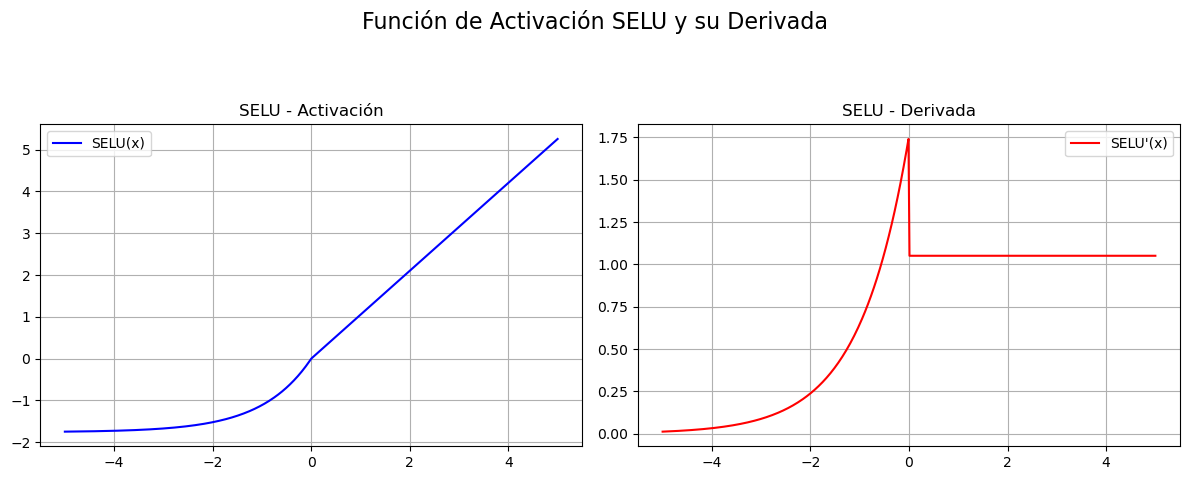

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parámetros de SELU
lambda_selu = 1.0507
alpha_selu = 1.6733

# Función y derivada de SELU
selu = lambda x: lambda_selu * np.where(x > 0, x, alpha_selu * (np.exp(x) - 1))
selu_deriv = lambda x: lambda_selu * np.where(x > 0, 1, alpha_selu * np.exp(x))

# Crear un rango de valores
x = np.linspace(-5, 5, 500)
y = selu(x)
dy = selu_deriv(x)

# Graficar
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Función de Activación SELU y su Derivada", fontsize=16)

# Activación
axs[0].plot(x, y, label='SELU(x)', color='blue')
axs[0].set_title("SELU - Activación")
axs[0].grid(True)
axs[0].legend()

# Derivada
axs[1].plot(x, dy, label="SELU'(x)", color='red')
axs[1].set_title("SELU - Derivada")
axs[1].grid(True)
axs[1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.show()


# Función de Activación: Maxout

La función **Maxout** es una generalización de ReLU que puede aprender tanto la activación como su forma. En lugar de aplicar una función fija, Maxout selecciona el máximo entre varias funciones lineales.

## Definición

Para un vector $z = [z_1, z_2, \dots, z_k]$, la activación Maxout se define como:

$$
\text{Maxout}(z_1, \dots, z_k) = \max_{i} z_i
$$

En una red neuronal, cada unidad Maxout calcula varios preactivaciones lineales y toma el máximo. Es especialmente útil en combinación con dropout y redes profundas.

> **Nota:** La función Maxout **no es diferenciable** en los puntos donde hay empate entre dos o más entradas. Sin embargo, es subdiferenciable y se puede optimizar con descenso del gradiente subdiferencial.


In [29]:
# Definición de la función Maxout y subgradiente
def maxout(z1, z2):
    return np.maximum(z1, z2)

def maxout_subgradient(z1, z2):
    # Retorna 1 donde z1 > z2, 0 donde z1 < z2, y 0.5 donde son iguales
    return np.where(z1 > z2, 1.0, np.where(z1 < z2, 0.0, 0.5))


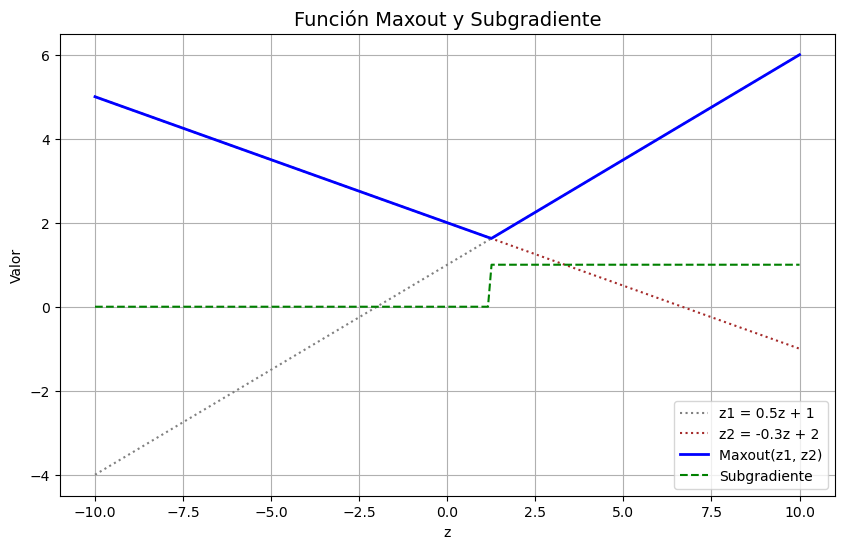

In [30]:
# Visualización de Maxout entre dos líneas
z = np.linspace(-10, 10, 200)
z1 = 0.5 * z + 1
z2 = -0.3 * z + 2

mout = maxout(z1, z2)
grad = maxout_subgradient(z1, z2)

plt.figure(figsize=(10, 6))
plt.plot(z, z1, label='z1 = 0.5z + 1', linestyle=':', color='gray')
plt.plot(z, z2, label='z2 = -0.3z + 2', linestyle=':', color='brown')
plt.plot(z, mout, label='Maxout(z1, z2)', color='blue', linewidth=2)
plt.plot(z, grad, label='Subgradiente', color='green', linestyle='--')
plt.title("Función Maxout y Subgradiente", fontsize=14)
plt.xlabel("z")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()


# Función de Activación: Softmax

La función **softmax** es utilizada principalmente en la capa de salida de clasificadores multiclase. Transforma un vector de valores reales en una distribución de probabilidad.

## Definición

Dado un vector $ \mathbf{z} = [z_1, z_2, \dots, z_K] $, la función softmax se define como:

$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \quad \text{para } i = 1, \dots, K
$$

El resultado es un vector cuyas componentes están en el intervalo $ (0, 1) $ y suman 1.

## Derivada

La derivada de la función softmax no es escalar, sino una **matriz Jacobiana**, cuya forma general es:

$$
\frac{\partial \text{softmax}(z)_i}{\partial z_j} =
\begin{cases}
\text{softmax}(z)_i \left(1 - \text{softmax}(z)_i\right), & \text{si } i = j \\
- \text{softmax}(z)_i \cdot \text{softmax}(z)_j, & \text{si } i \ne j
\end{cases}
$$

De manera equivalente, si denotamos $ \hat{y}_k = \text{softmax}(z_k) $, entonces la derivada se puede expresar como:

$$
\frac{\partial \hat{y}_k}{\partial z_i} =
\begin{cases}
\hat{y}_k(1 - \hat{y}_k), & \text{si } k = i \\
- \hat{y}_k \hat{y}_i, & \text{si } k \ne i
\end{cases}
$$

Esta propiedad es fundamental en el cálculo del gradiente durante el proceso de retropropagación, especialmente cuando se combina con la función de pérdida **log-loss** (también llamada entropía cruzada).


In [31]:
import numpy as np

def softmax(z):
    z = np.array(z)
    shift_z = z - np.max(z)  # Estabilidad numérica
    exp_z = np.exp(shift_z)
    return exp_z / np.sum(exp_z)

def softmax_jacobian(s):
    """Calcula la matriz Jacobiana del vector softmax s"""
    s = s.reshape(-1, 1)
    return np.diagflat(s) - s @ s.T


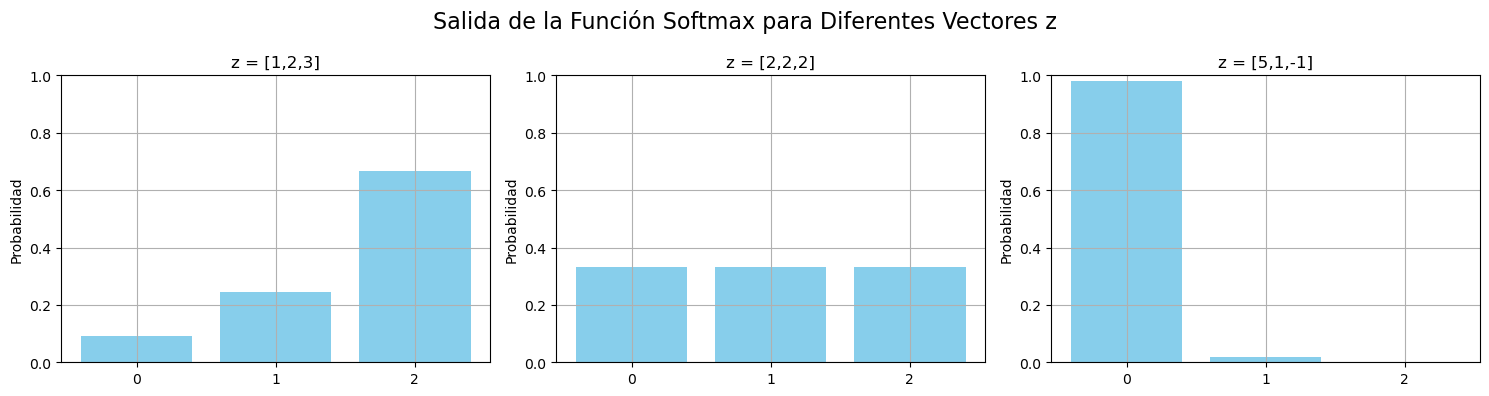

In [32]:
import matplotlib.pyplot as plt

# Generar vectores
z1 = [1, 2, 3]
z2 = [2, 2, 2]
z3 = [5, 1, -1]

# Aplicar softmax
s1 = softmax(z1)
s2 = softmax(z2)
s3 = softmax(z3)

# Visualizar como barras
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for ax, s, title in zip(axs, [s1, s2, s3], ['z = [1,2,3]', 'z = [2,2,2]', 'z = [5,1,-1]']):
    ax.bar(range(len(s)), s, color='skyblue')
    ax.set_title(title)
    ax.set_ylim(0, 1)
    ax.set_xticks([0, 1, 2])
    ax.set_ylabel('Probabilidad')
    ax.grid(True)

plt.suptitle("Salida de la Función Softmax para Diferentes Vectores z", fontsize=16)
plt.tight_layout()
plt.show()


# Función de Activación: Swish

La función **Swish** fue propuesta por Google como una alternativa suave y no monótona a ReLU. Combina las ventajas de funciones suaves como Sigmoid con la simplicidad de ReLU.

## Definición

Dado un valor $z$, la función Swish se define como:

$$
\text{swish}(z) = z \cdot \sigma(z) = \frac{z}{1 + e^{-z}}
$$

donde $\sigma(z)$ es la función sigmoid.

## Derivada

La derivada de Swish es:

$$
\text{swish}'(z) = \sigma(z) + z \cdot \sigma'(z)
= \sigma(z) + z \cdot \sigma(z)(1 - \sigma(z))
$$

Es decir:

$$
\text{swish}'(z) = \sigma(z) \left(1 + z (1 - \sigma(z)) \right)
$$

Swish es diferenciable en todos los puntos y ha demostrado mejorar el rendimiento en redes profundas.


In [33]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def swish(z):
    return z * sigmoid(z)

def swish_derivative(z):
    s = sigmoid(z)
    return s + z * s * (1 - s)


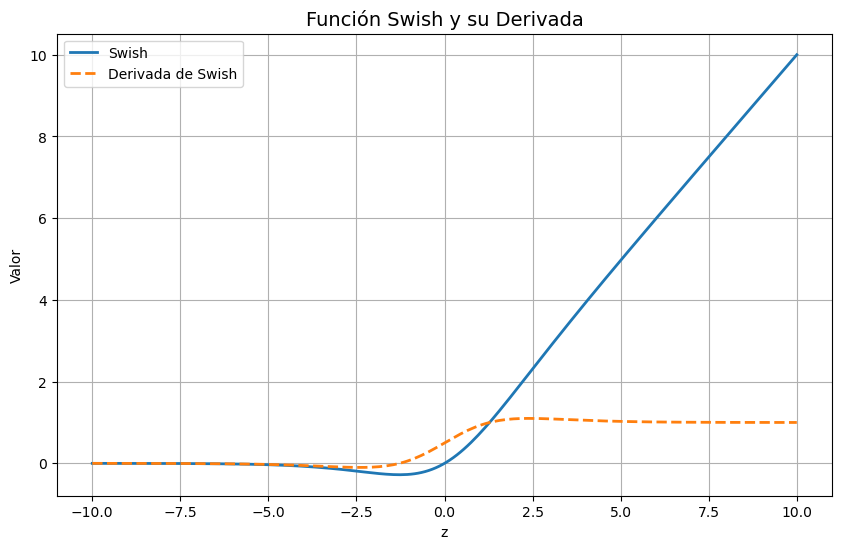

In [34]:
import matplotlib.pyplot as plt

z = np.linspace(-10, 10, 200)
s = swish(z)
ds = swish_derivative(z)

plt.figure(figsize=(10, 6))
plt.plot(z, s, label='Swish', linewidth=2)
plt.plot(z, ds, label='Derivada de Swish', linestyle='--', linewidth=2)
plt.title("Función Swish y su Derivada", fontsize=14)
plt.xlabel("z")
plt.ylabel("Valor")
plt.grid(True)
plt.legend()
plt.show()


# Función de Activación: GELU (Gaussian Error Linear Unit)

La función **GELU** es una función de activación suave propuesta para mejorar la capacidad de generalización de las redes neuronales profundas. Ha sido ampliamente adoptada en arquitecturas modernas como BERT y transformers.

## Definición

La versión exacta de GELU es:

$$
\text{GELU}(z) = z \cdot \Phi(z)
$$

donde $\Phi(z)$ es la función de distribución acumulada (CDF) de una distribución normal estándar:

$$
\Phi(z) = \frac{1}{2} \left[1 + \text{erf}\left(\frac{z}{\sqrt{2}}\right)\right]
$$

Existe una **aproximación rápida** frecuentemente usada:

$$
\text{GELU}(z) \approx 0.5 z \left(1 + \tanh\left(\sqrt{\frac{2}{\pi}}(z + 0.044715 z^3)\right)\right)
$$

Esta versión es más eficiente computacionalmente y suficientemente precisa para la mayoría de los usos prácticos.

## Derivada de la Función GELU (Aproximada)

La derivada de la versión aproximada de GELU (usada en la práctica) es:

$$
\frac{d}{dz} \text{GELU}(z) \approx 0.5 \left(1 + \tanh\left(\sqrt{\frac{2}{\pi}} (z + 0.044715 z^3) \right) \right) + \\
0.5 z \cdot \left(1 - \tanh^2\left(\sqrt{\frac{2}{\pi}} (z + 0.044715 z^3) \right)\right) \cdot \sqrt{\frac{2}{\pi}} (1 + 3 \cdot 0.044715 \cdot z^2)
$$

Es compleja pero computable, y útil para graficar la pendiente que introduce esta activación suave.



In [35]:
import numpy as np
from scipy.special import erf

def gelu_exact(z):
    return z * 0.5 * (1 + erf(z / np.sqrt(2)))

def gelu_approx(z):
    return 0.5 * z * (1 + np.tanh(np.sqrt(2 / np.pi) * (z + 0.044715 * z**3)))

def gelu_approx_derivative(z):
    sqrt_term = np.sqrt(2 / np.pi)
    inner = sqrt_term * (z + 0.044715 * z**3)
    tanh_inner = np.tanh(inner)
    sech2 = 1 - tanh_inner**2  # derivada de tanh
    return 0.5 * (1 + tanh_inner) + 0.5 * z * sech2 * sqrt_term * (1 + 3 * 0.044715 * z**2)


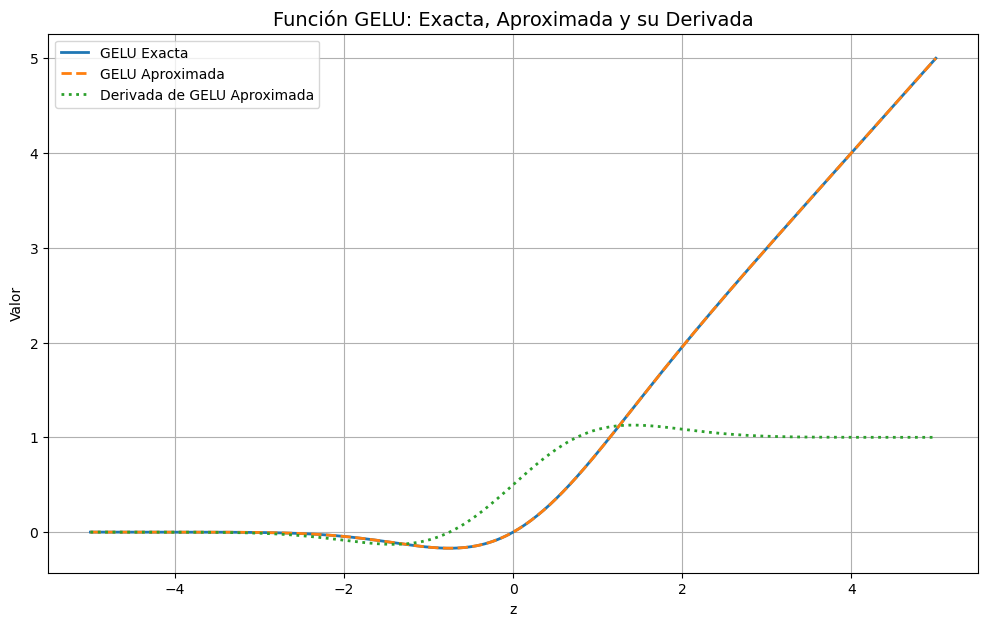

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import erf

# Definiciones
def gelu_exact(z):
    return 0.5 * z * (1 + erf(z / np.sqrt(2)))

def gelu_approx(z):
    return 0.5 * z * (1 + np.tanh(np.sqrt(2/np.pi) * (z + 0.044715 * z**3)))

def gelu_approx_derivative(z):
    sqrt_term = np.sqrt(2 / np.pi)
    inner = sqrt_term * (z + 0.044715 * z**3)
    tanh_inner = np.tanh(inner)
    sech2 = 1 - tanh_inner**2
    return 0.5 * (1 + tanh_inner) + 0.5 * z * sech2 * sqrt_term * (1 + 3 * 0.044715 * z**2)

# Rango de entrada
z = np.linspace(-5, 5, 400)
gelu_e = gelu_exact(z)
gelu_a = gelu_approx(z)
dgelu_a = gelu_approx_derivative(z)

# Gráfica
plt.figure(figsize=(12, 7))
plt.plot(z, gelu_e, label='GELU Exacta', linewidth=2)
plt.plot(z, gelu_a, '--', label='GELU Aproximada', linewidth=2)
plt.plot(z, dgelu_a, ':', label='Derivada de GELU Aproximada', linewidth=2)
plt.title("Función GELU: Exacta, Aproximada y su Derivada", fontsize=14)
plt.xlabel("z")
plt.ylabel("Valor")
plt.grid(True)
plt.legend()
plt.show()


---
# Modelos Lineales para Clasificación Multiclase
---

## Usando el **Perceptrón** definido en la biblioteca sklearn

## Clasificación Multiclase One-vs-One: Votación

### 1. Entrenamiento

Para un conjunto con $ K $ clases, se entrena un clasificador binario para **cada par de clases**:

$$
\text{Número de clasificadores} = \binom{K}{2} = \frac{K(K-1)}{2}
$$

Cada clasificador $ h_{ij} $ se entrena únicamente con ejemplos de las clases $ i $ y $ j $.

---

### 2. Predicción: Votación por Mayoría

Para un nuevo punto $ \mathbf{x} $, cada clasificador $ h_{ij} $ emite un voto:

- Si $ h_{ij}(\mathbf{x}) = +1 $, se vota por la clase $ i $.
- Si $ h_{ij}(\mathbf{x}) = -1 $, se vota por la clase $ j $.

Se cuentan los votos totales para cada clase y se predice la clase con **mayoría de votos**.

---

### 3. Ejemplo: Votación con 3 clases

Supongamos un problema con clases: $ 0, 1, 2 $. Se entrenan los clasificadores:

- $ h_{01} $
- $ h_{02} $
- $ h_{12} $

Y para una muestra $ \mathbf{x} $, se obtienen las siguientes predicciones:

- $ h_{01}(\mathbf{x}) = +1 $ → voto para clase 0  
- $ h_{02}(\mathbf{x}) = -1 $ → voto para clase 2  
- $ h_{12}(\mathbf{x}) = -1 $ → voto para clase 2  

**Conteo de votos:**

| Clase | Votos |
|-------|-------|
| 0     |   1   |
| 1     |   0   |
| 2     |   2   |

Por lo tanto, la clase predicha es: **clase 2**

---

### 4. Empates

En caso de empate (por ejemplo, 2 clases con la misma cantidad de votos), se puede:

- Escoger la clase con el índice más bajo (regla arbitraria).
- Usar una medida de confianza (por ejemplo, la distancia al hiperplano).
- Marcar la muestra como ambigua.

---

### Ventajas del método

- Simplicidad en la implementación.
- Buena precisión si los clasificadores binarios son efectivos.
- Escalable a cualquier número de clases.


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.linear_model import Perceptron
from itertools import combinations
from collections import defaultdict, Counter
from sklearn.preprocessing import OneHotEncoder

In [38]:
class OneVsOnePerceptron:
    def __init__(self):
        self.classifiers = dict()

    def fit(self, X, y):
        self.labels = np.unique(y)
        for i, j in combinations(self.labels, 2):
            # Filtrar datos para las clases i y j
            idx = np.where((y == i) | (y == j))[0]
            X_ij = X[idx]
            y_ij = np.where(y[idx] == i, 1, -1)
            clf = Perceptron(max_iter=1000)
            clf.fit(X_ij, y_ij)
            self.classifiers[(i, j)] = clf

    def predict(self, X):
        votes = np.zeros((X.shape[0], len(self.labels)), dtype=int)
        for (i, j), clf in self.classifiers.items():
            pred = clf.predict(X)
            for idx, p in enumerate(pred):
                if p == 1:
                    votes[idx, i] += 1
                else:
                    votes[idx, j] += 1
        return np.argmax(votes, axis=1)

    def predict_votes(self, x):
        vote_count = Counter()
        decisions = {}
        for (i, j), clf in self.classifiers.items():
            pred = clf.predict([x])[0]
            chosen = i if pred == 1 else j
            vote_count[chosen] += 1
            decisions[f"h_{i}{j}"] = f"Voto por clase {chosen}"
        final = vote_count.most_common(1)[0][0]
        return decisions, vote_count, final

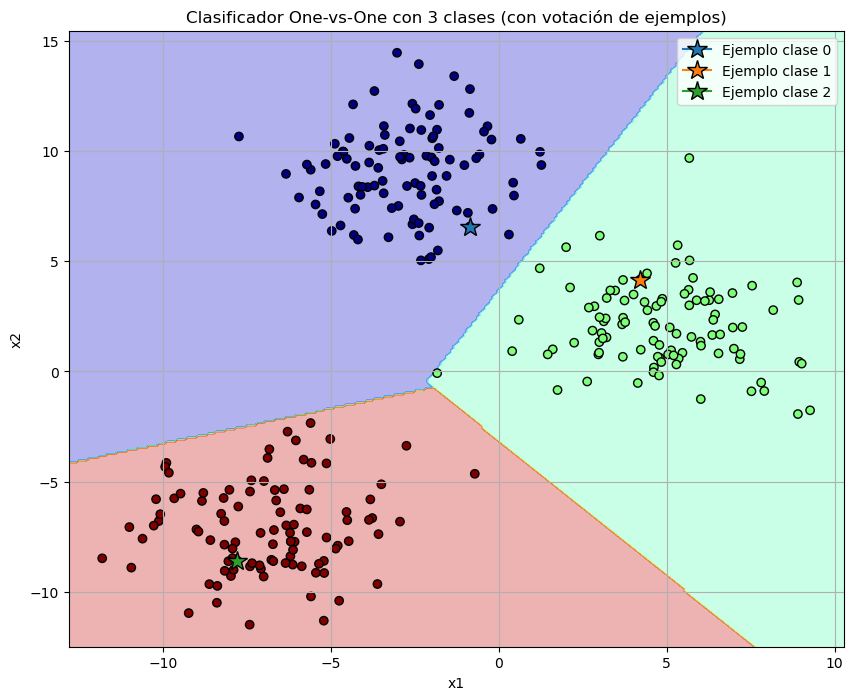

In [39]:
# ======= Generar datos y entrenar =======
X, y = make_blobs(n_samples=300, centers=3, random_state=42, cluster_std=2)
ovo = OneVsOnePerceptron()
ovo.fit(X, y)

# ======= Tomar un punto por clase =======
ejemplos = [X[y == i][0] for i in range(3)]

# ======= Visualización =======
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = ovo.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.jet)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.jet)

# Dibujar puntos seleccionados
for i, punto in enumerate(ejemplos):
    plt.plot(punto[0], punto[1], marker='*', markersize=15, markeredgecolor='black', label=f"Ejemplo clase {i}")

plt.title("Clasificador One-vs-One con 3 clases (con votación de ejemplos)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
# ======= Mostrar decisiones de votación =======
for i, punto in enumerate(ejemplos):
    print(f"\n📌 Punto de clase {i}: {punto}")
    decisiones, votos, final = ovo.predict_votes(punto)
    for clave, valor in decisiones.items():
        print(f"  {clave}: {valor}")
    print(f"  🗳️ Conteo de votos: {dict(votos)}")
    print(f"  ✅ Clase predicha: {final}")


📌 Punto de clase 0: [-0.8641078   6.57259883]
  h_01: Voto por clase 0
  h_02: Voto por clase 0
  h_12: Voto por clase 1
  🗳️ Conteo de votos: {0: 2, 1: 1}
  ✅ Clase predicha: 0

📌 Punto de clase 1: [4.20451643 4.17072339]
  h_01: Voto por clase 1
  h_02: Voto por clase 0
  h_12: Voto por clase 1
  🗳️ Conteo de votos: {1: 2, 0: 1}
  ✅ Clase predicha: 1

📌 Punto de clase 2: [-7.79834899 -8.57979833]
  h_01: Voto por clase 0
  h_02: Voto por clase 2
  h_12: Voto por clase 2
  🗳️ Conteo de votos: {0: 1, 2: 2}
  ✅ Clase predicha: 2


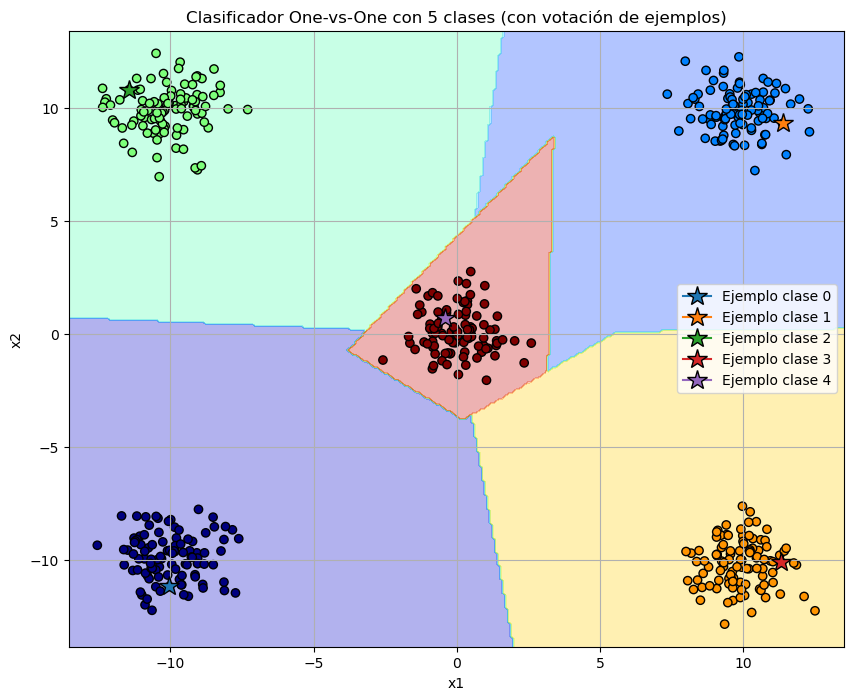

In [41]:
# ======= Generar datos (5 clases, bien separadas) =======
centros = [[-10, -10], [10, 10], [-10, 10], [10, -10], [0, 0]]
X, y = make_blobs(n_samples=500, centers=centros, cluster_std=1.0, random_state=0)

# Entrenamiento
ovo5 = OneVsOnePerceptron()
ovo5.fit(X, y)

# Seleccionar un punto representativo por clase
ejemplos = [X[y == i][0] for i in range(5)]

# ======= Visualización =======
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = ovo5.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.jet)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.jet)

# Dibujar los puntos seleccionados
for i, punto in enumerate(ejemplos):
    plt.plot(punto[0], punto[1], marker='*', markersize=15, markeredgecolor='black', label=f"Ejemplo clase {i}")

plt.title("Clasificador One-vs-One con 5 clases (con votación de ejemplos)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

In [42]:
# ======= Mostrar votación de cada hiperplano para los puntos =======
for i, punto in enumerate(ejemplos):
    print(f"\n📌 Punto de clase {i}: {punto}")
    decisiones, votos, final = ovo5.predict_votes(punto)
    for clave, valor in sorted(decisiones.items()):
        print(f"  {clave}: {valor}")
    print(f"  🗳️ Conteo de votos: {dict(votos)}")
    print(f"  ✅ Clase predicha: {final}")


📌 Punto de clase 0: [-10.03928282 -11.1680935 ]
  h_01: Voto por clase 0
  h_02: Voto por clase 0
  h_03: Voto por clase 0
  h_04: Voto por clase 0
  h_12: Voto por clase 2
  h_13: Voto por clase 3
  h_14: Voto por clase 4
  h_23: Voto por clase 3
  h_24: Voto por clase 4
  h_34: Voto por clase 3
  🗳️ Conteo de votos: {0: 4, 2: 1, 3: 3, 4: 2}
  ✅ Clase predicha: 0

📌 Punto de clase 1: [11.36453185  9.31055082]
  h_01: Voto por clase 1
  h_02: Voto por clase 2
  h_03: Voto por clase 3
  h_04: Voto por clase 4
  h_12: Voto por clase 1
  h_13: Voto por clase 1
  h_14: Voto por clase 1
  h_23: Voto por clase 3
  h_24: Voto por clase 4
  h_34: Voto por clase 4
  🗳️ Conteo de votos: {1: 4, 2: 1, 3: 2, 4: 3}
  ✅ Clase predicha: 1

📌 Punto de clase 2: [-11.4465347   10.80029795]
  h_01: Voto por clase 0
  h_02: Voto por clase 2
  h_03: Voto por clase 0
  h_04: Voto por clase 4
  h_12: Voto por clase 2
  h_13: Voto por clase 1
  h_14: Voto por clase 4
  h_23: Voto por clase 2
  h_24: Voto por 

## Clasificación Multiclase One-vs-Rest: Clasificadores Independientes

### 1. Entrenamiento

Para un conjunto con $ K $ clases, se entrena un clasificador binario por cada clase:

$$
\text{Número de clasificadores} = K
$$

Cada clasificador $ h_k $ se entrena para distinguir la clase $ k $ frente a todas las demás:

- Etiquetas: $ y = +1 $ si pertenece a la clase $ k $, $ y = -1 $ si pertenece a otra clase.

---

### 2. Predicción: Mayor Activación

Para un nuevo punto $ \mathbf{x} $, cada clasificador $ h_k $ devuelve una puntuación (ej., $ s_k = \mathbf{w}_k^\top \mathbf{x} $). Se predice la clase con la puntuación más alta:

$$
\hat{y} = \arg\max_k \, s_k(\mathbf{x})
$$

---

### 3. Ejemplo: Clasificación con 3 clases

Supongamos un problema con clases: $ 0, 1, 2 $. Se entrenan los clasificadores:

- $ h_0 $ vs resto  
- $ h_1 $ vs resto  
- $ h_2 $ vs resto

Para una muestra $ \mathbf{x} $, se obtienen las salidas:

- $ s_0(\mathbf{x}) = -1.3 $
- $ s_1(\mathbf{x}) = +2.1 $
- $ s_2(\mathbf{x}) = +0.7 $

**Puntuaciones:**

| Clase | Puntuación |
|-------|------------|
| 0     |   -1.3     |
| 1     |   +2.1     |
| 2     |   +0.7     |

Se predice: **clase 1**, al tener la mayor puntuación.

---

### 4. Manejo de Ambigüedades

En caso de puntuaciones similares entre varias clases, se puede:

- Elegir la clase con mayor margen.
- Introducir calibración de probabilidades.
- Aplicar reglas de desempate arbitrarias.

---

### Ventajas del método

- Simplicidad de implementación y entrenamiento.
- Compatible con cualquier clasificador binario.
- Bien escalado a conjuntos grandes de datos.

---

### Limitaciones

- Los clasificadores no interactúan entre sí, lo que puede producir zonas de ambigüedad.
- Puede haber solapamiento entre regiones de decisión.
- No garantiza una distribución bien calibrada de las salidas.


In [43]:
class OneVsRestPerceptron:
    def __init__(self):
        self.classifiers = dict()

    def fit(self, X, y):
        self.labels = np.unique(y)
        for k in self.labels:
            y_k = np.where(y == k, 1, -1)
            clf = Perceptron(max_iter=1000)
            clf.fit(X, y_k)
            self.classifiers[k] = clf

    def predict(self, X):
        scores = np.array([clf.decision_function(X) for clf in self.classifiers.values()])
        return np.argmax(scores, axis=0)

    def predict_scores(self, x):
        decisions = {}
        scores = {}
        for k, clf in self.classifiers.items():
            s = clf.decision_function([x])[0]
            scores[k] = s
            decisions[f"g_{k}"] = f"Score = {s:.2f}"
        final = max(scores, key=scores.get)
        return decisions, scores, final

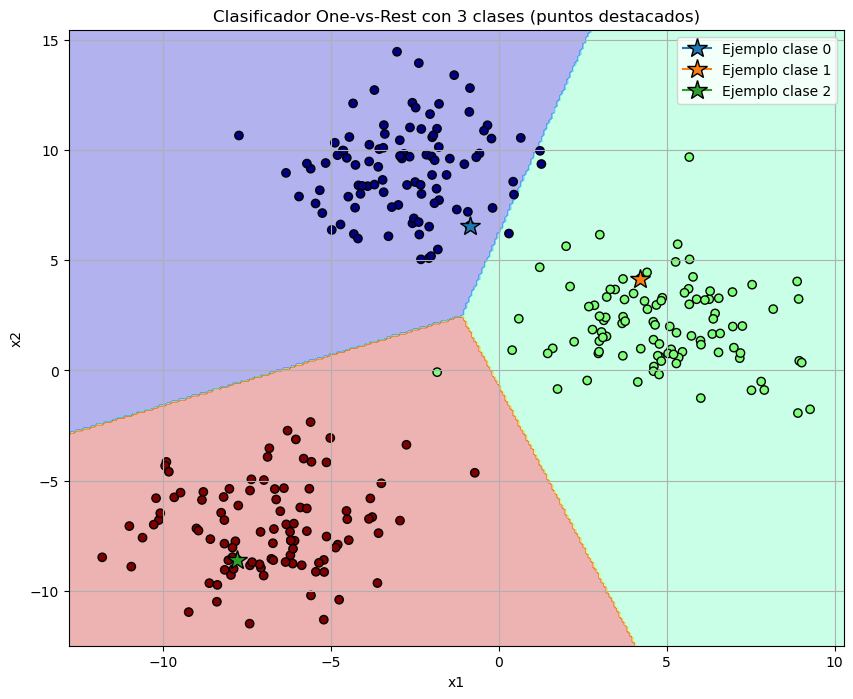


📌 Punto de clase 0: [-0.8641078   6.57259883]
  g_0: Score = 17.76
  g_1: Score = -13.86
  g_2: Score = -54.26
  ✅ Clase predicha: 0

📌 Punto de clase 1: [4.20451643 4.17072339]
  g_0: Score = -60.08
  g_1: Score = 96.90
  g_2: Score = -46.81
  ✅ Clase predicha: 1

📌 Punto de clase 2: [-7.79834899 -8.57979833]
  g_0: Score = -68.69
  g_1: Score = -180.40
  g_2: Score = 76.13
  ✅ Clase predicha: 2


In [44]:
# ========== Datos para 3 clases ==========
X, y = make_blobs(n_samples=300, centers=3, random_state=42, cluster_std=2)
ovr = OneVsRestPerceptron()
ovr.fit(X, y)

# Un punto de cada clase
ejemplos = [X[y == i][0] for i in range(3)]

# Visualización de regiones
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = ovr.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.jet)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.jet)

for i, punto in enumerate(ejemplos):
    plt.plot(punto[0], punto[1], marker='*', markersize=15, markeredgecolor='black', label=f"Ejemplo clase {i}")

plt.title("Clasificador One-vs-Rest con 3 clases (puntos destacados)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Mostrar votación de cada clasificador
for i, punto in enumerate(ejemplos):
    print(f"\n📌 Punto de clase {i}: {punto}")
    decisiones, scores, final = ovr.predict_scores(punto)
    for clave, valor in decisiones.items():
        print(f"  {clave}: {valor}")
    print(f"  ✅ Clase predicha: {final}")

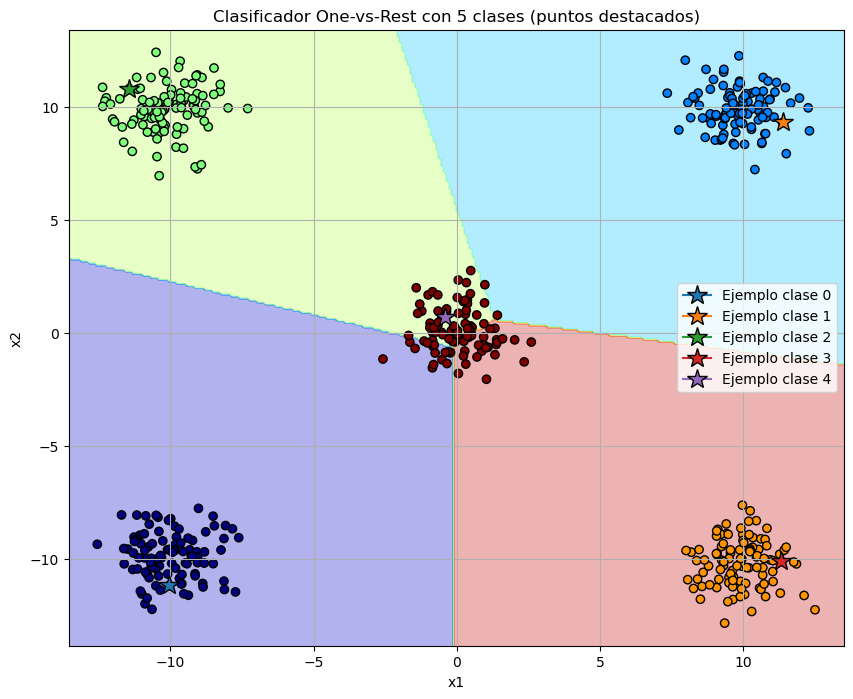


📌 Punto de clase 0: [-10.03928282 -11.1680935 ]
  g_0: Score = 109.89
  g_1: Score = -228.81
  g_2: Score = -50.00
  g_3: Score = -22.93
  g_4: Score = 3.88
  ✅ Clase predicha: 0

📌 Punto de clase 1: [11.36453185  9.31055082]
  g_0: Score = -184.46
  g_1: Score = 126.99
  g_2: Score = -26.03
  g_3: Score = -30.00
  g_4: Score = -89.02
  ✅ Clase predicha: 1

📌 Punto de clase 2: [-11.4465347   10.80029795]
  g_0: Score = -32.25
  g_1: Score = -59.37
  g_2: Score = 64.11
  g_3: Score = -182.94
  g_4: Score = -84.10
  ✅ Clase predicha: 2

📌 Punto de clase 3: [ 11.3277827  -10.10128149]
  g_0: Score = -49.74
  g_1: Score = -33.89
  g_2: Score = -122.21
  g_3: Score = 103.39
  g_4: Score = -10.66
  ✅ Clase predicha: 3

📌 Punto de clase 4: [-0.40594173  0.7243685 ]
  g_0: Score = -41.13
  g_1: Score = -46.54
  g_2: Score = -25.93
  g_3: Score = -44.53
  g_4: Score = -48.73
  ✅ Clase predicha: 2


In [45]:
# ========== Datos para 5 clases ==========
centros = [[-10, -10], [10, 10], [-10, 10], [10, -10], [0, 0]]
X, y = make_blobs(n_samples=500, centers=centros, cluster_std=1.0, random_state=0)
ovr5 = OneVsRestPerceptron()
ovr5.fit(X, y)

ejemplos = [X[y == i][0] for i in range(5)]

# Visualización
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = ovr5.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.jet)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.jet)

for i, punto in enumerate(ejemplos):
    plt.plot(punto[0], punto[1], marker='*', markersize=15, markeredgecolor='black', label=f"Ejemplo clase {i}")

plt.title("Clasificador One-vs-Rest con 5 clases (puntos destacados)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Mostrar resultados para puntos destacados
for i, punto in enumerate(ejemplos):
    print(f"\n📌 Punto de clase {i}: {punto}")
    decisiones, scores, final = ovr5.predict_scores(punto)
    for clave, valor in sorted(decisiones.items()):
        print(f"  {clave}: {valor}")
    print(f"  ✅ Clase predicha: {final}")

## Clasificación Multiclase con Perceptrón Multiclase

### 1. Arquitectura del Modelo

El Perceptrón Multiclase extiende el perceptrón binario al caso de múltiples clases. Se utiliza una capa lineal con una neurona por clase.

Para $K$ clases y entrada $\mathbf{x} \in \mathbb{R}^d$:

$$
\mathbf{z} = \mathbf{W} \mathbf{x} + \mathbf{b}, \quad \mathbf{W} \in \mathbb{R}^{K \times d}, \quad \mathbf{b} \in \mathbb{R}^K
$$

Cada componente $z_k$ representa la activación de la clase $k$.

---

### 2. Regla de Predicción

Se predice la clase con mayor activación (similar a argmax):

$$
\hat{y} = \arg\max_k \, z_k = \arg\max_k \, \left( \mathbf{w}_k^\top \mathbf{x} + b_k \right)
$$

---

### 3. Algoritmo de Entrenamiento

Para cada ejemplo $(\mathbf{x}, y)$:

1. Calcular activaciones: $\mathbf{z} = \mathbf{W} \mathbf{x} + \mathbf{b}$
2. Obtener la clase predicha: $\hat{y} = \arg\max_k \, z_k$
3. Si $\hat{y} \ne y$:
   - Penalizar la clase predicha: $\mathbf{w}_{\hat{y}} \leftarrow \mathbf{w}_{\hat{y}} - \eta \mathbf{x}$
   - Recompensar la clase correcta: $\mathbf{w}_{y} \leftarrow \mathbf{w}_{y} + \eta \mathbf{x}$

Donde $\eta$ es la tasa de aprendizaje.

---

### 4. Ejemplo de Clasificación con 3 Clases

Supongamos un problema con clases: $0, 1, 2$.  
Una muestra $\mathbf{x}$ da las siguientes activaciones:

- $z_0 = -1.2$
- $z_1 = +0.5$
- $z_2 = +2.3$

**Tabla de Activaciones:**

| Clase | Activación |
|-------|------------|
| 0     | -1.2       |
| 1     | +0.5       |
| 2     | +2.3       |

Se predice: **clase 2**, por ser la mayor activación.

---

### 5. Manejo de Ambigüedades

Si hay empate entre clases (activaciones iguales), se puede:

- Escoger la clase con menor índice (por convención).
- Usar desempates aleatorios.
- Introducir regularización o ajustes en el criterio de decisión.

---

### Ventajas

- Arquitectura simple y eficiente.
- Todo el modelo se entrena de forma conjunta.
- Natural para representar problemas linealmente separables multiclase.

---

### Limitaciones

- No modela incertidumbre (no devuelve probabilidades).
- Función de pérdida no diferenciable, lo que limita extensiones a gradiente.
- Sólo funciona con datos linealmente separables.

---


In [46]:
class MultiClassPerceptron:
    def __init__(self, n_classes, n_features, lr=1.0, max_iter=1000):
        self.n_classes = n_classes
        self.n_features = n_features
        self.lr = lr
        self.max_iter = max_iter
        self.W = np.zeros((n_classes, n_features))  # Matriz de pesos: [clases x características]

    def fit(self, X, y):
        for _ in range(self.max_iter):
            for xi, yi in zip(X, y):
                scores = self.W @ xi
                y_pred = np.argmax(scores)
                if y_pred != yi:
                    self.W[yi] += self.lr * xi
                    self.W[y_pred] -= self.lr * xi

    def predict(self, X):
        scores = self.W @ X.T
        return np.argmax(scores, axis=0)

    def predict_scores(self, x):
        scores = self.W @ x
        return {f"s_{i}": score for i, score in enumerate(scores)}, np.argmax(scores)

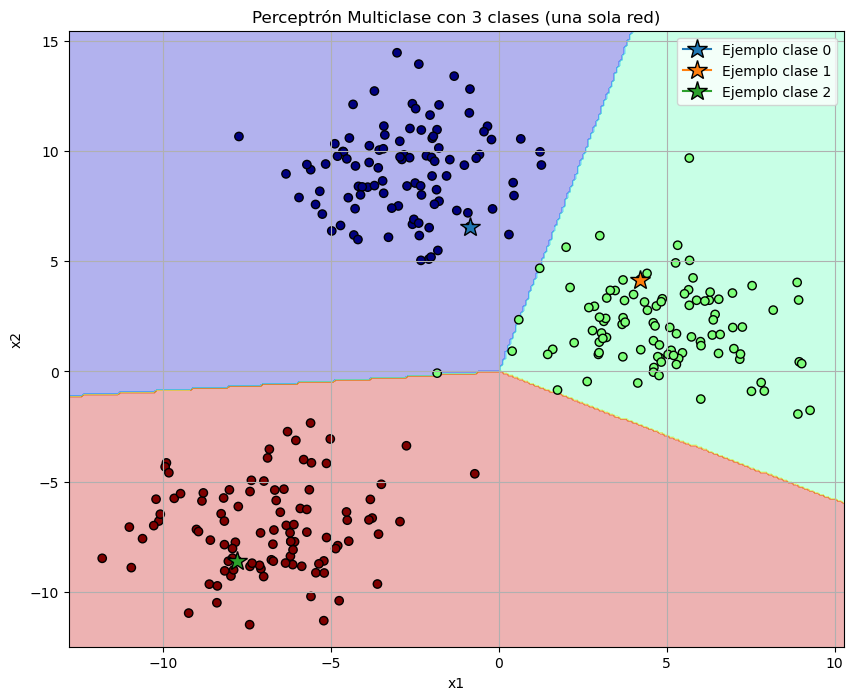


📌 Punto de clase 0: [-0.8641078   6.57259883]
  s_0 = 99.00
  s_1 = 44.66
  s_2 = -143.66
  ✅ Clase predicha: 0

📌 Punto de clase 1: [4.20451643 4.17072339]
  s_0 = 24.04
  s_1 = 90.68
  s_2 = -114.73
  ✅ Clase predicha: 1

📌 Punto de clase 2: [-7.79834899 -8.57979833]
  s_0 = -56.40
  s_1 = -175.39
  s_2 = 231.79
  ✅ Clase predicha: 2


In [47]:
# === Datos para 3 clases ===
X, y = make_blobs(n_samples=300, centers=3, random_state=42, cluster_std=2)
n_classes = len(np.unique(y))
n_features = X.shape[1]

multi = MultiClassPerceptron(n_classes, n_features)
multi.fit(X, y)

# Tomar un punto por clase
ejemplos = [X[y == i][0] for i in range(n_classes)]

# Visualización
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = multi.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.jet)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.jet)

for i, punto in enumerate(ejemplos):
    plt.plot(punto[0], punto[1], marker='*', markersize=15,
             markeredgecolor='black', label=f"Ejemplo clase {i}")

plt.title("Perceptrón Multiclase con 3 clases (una sola red)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Mostrar puntuaciones
for i, punto in enumerate(ejemplos):
    print(f"\n📌 Punto de clase {i}: {punto}")
    scores, pred = multi.predict_scores(punto)
    for k, s in scores.items():
        print(f"  {k} = {s:.2f}")
    print(f"  ✅ Clase predicha: {pred}")

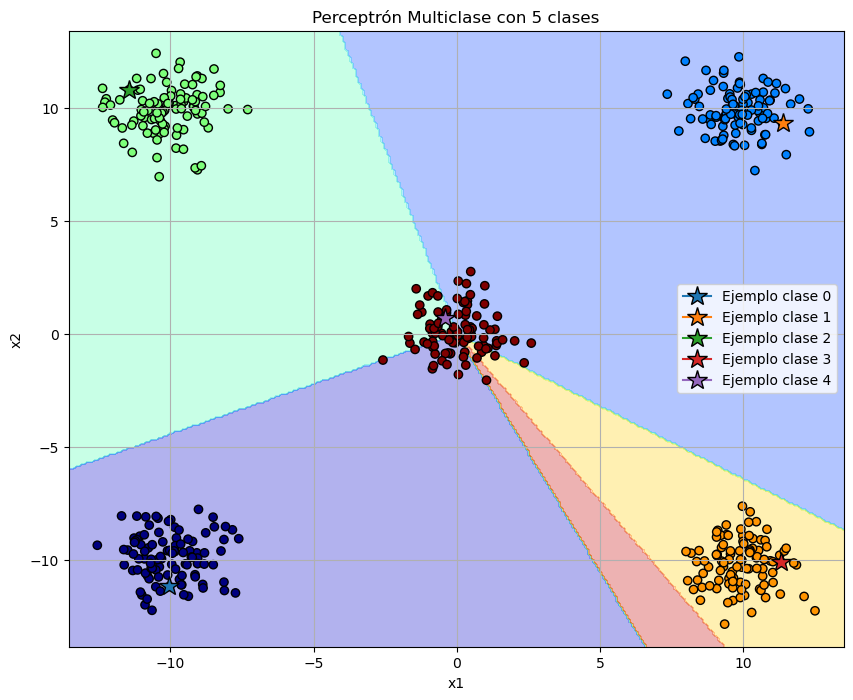


📌 Punto de clase 0: [-10.03928282 -11.1680935 ]
  s_0 = 138.74
  s_1 = -303.65
  s_2 = 36.50
  s_3 = 45.58
  s_4 = 82.83
  ✅ Clase predicha: 0

📌 Punto de clase 1: [11.36453185  9.31055082]
  s_0 = -128.36
  s_1 = 295.89
  s_2 = -63.26
  s_3 = -33.44
  s_4 = -70.83
  ✅ Clase predicha: 1

📌 Punto de clase 2: [-11.4465347   10.80029795]
  s_0 = -44.52
  s_1 = -8.27
  s_2 = 196.63
  s_3 = -76.33
  s_4 = -67.50
  ✅ Clase predicha: 2

📌 Punto de clase 3: [ 11.3277827  -10.10128149]
  s_0 = 39.00
  s_1 = 16.61
  s_2 = -190.72
  s_3 = 72.34
  s_4 = 62.77
  ✅ Clase predicha: 3

📌 Punto de clase 4: [-0.40594173  0.7243685 ]
  s_0 = -4.52
  s_1 = 4.61
  s_2 = 9.22
  s_3 = -4.57
  s_4 = -4.74
  ✅ Clase predicha: 2


In [48]:
# === Versión con 5 clases ===
centros = [[-10, -10], [10, 10], [-10, 10], [10, -10], [0, 0]]
X, y = make_blobs(n_samples=500, centers=centros, cluster_std=1.0, random_state=0)
n_classes = len(np.unique(y))
n_features = X.shape[1]

multi5 = MultiClassPerceptron(n_classes, n_features)
multi5.fit(X, y)

ejemplos = [X[y == i][0] for i in range(n_classes)]

# Visualización
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = multi5.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.jet)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.jet)

for i, punto in enumerate(ejemplos):
    plt.plot(punto[0], punto[1], marker='*', markersize=15,
             markeredgecolor='black', label=f"Ejemplo clase {i}")

plt.title("Perceptrón Multiclase con 5 clases")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Mostrar puntuaciones
for i, punto in enumerate(ejemplos):
    print(f"\n📌 Punto de clase {i}: {punto}")
    scores, pred = multi5.predict_scores(punto)
    for k, s in sorted(scores.items()):
        print(f"  {k} = {s:.2f}")
    print(f"  ✅ Clase predicha: {pred}")

## Clasificación Multiclase con Regresión Softmax

### 1. Arquitectura del Modelo

La regresión Softmax extiende la regresión logística binaria a múltiples clases.

Dado un ejemplo de entrada $ \mathbf{x} \in \mathbb{R}^d $ y $K$ clases:

$$
\mathbf{z} = \mathbf{W} \mathbf{x} + \mathbf{b}, \quad \mathbf{z} \in \mathbb{R}^K
$$

Donde:
- $\mathbf{W} \in \mathbb{R}^{K \times d}$ son los pesos por clase.
- $\mathbf{b} \in \mathbb{R}^K$ es el vector de sesgo.
- $\mathbf{z}$ son las puntuaciones (logits) por clase.

---

### 2. Cálculo de Probabilidades: Función Softmax

Para convertir los logits $z_k$ en probabilidades, se aplica la función softmax:

$$
P(y = k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}} = \frac{e^{\mathbf{w}_k^\top \mathbf{x} + b_k}}{\sum_{j=1}^{K} e^{\mathbf{w}_j^\top \mathbf{x} + b_j}}
$$

Esto asegura que:

- $P(y=k|\mathbf{x}) \in [0, 1]$
- $\sum_k P(y=k|\mathbf{x}) = 1$

---

### 3. Regla de Decisión

Se predice la clase con mayor probabilidad:

$$
\hat{y} = \arg\max_k \, P(y = k \mid \mathbf{x})
$$

---

### 4. Función de Pérdida: Log-Loss (Entropía Cruzada)

Se utiliza la pérdida de entropía cruzada (cross-entropy) sobre las probabilidades softmax:

$$
\mathcal{L}(\mathbf{x}, y) = -\log P(y \mid \mathbf{x}) = -\log \left( \frac{e^{z_y}}{\sum_j e^{z_j}} \right)
$$

Donde $z_y$ es el logit correspondiente a la clase verdadera.

---

### 5. Ejemplo Numérico

Supongamos un ejemplo $\mathbf{x}$ con logits:

- $z_0 = 1.0$
- $z_1 = 2.0$
- $z_2 = 0.5$

Se calculan las probabilidades softmax:

$$
\begin{aligned}
P_0 &= \frac{e^{1.0}}{e^{1.0} + e^{2.0} + e^{0.5}} \approx 0.211 \\
P_1 &= \frac{e^{2.0}}{e^{1.0} + e^{2.0} + e^{0.5}} \approx 0.576 \\
P_2 &= \frac{e^{0.5}}{e^{1.0} + e^{2.0} + e^{0.5}} \approx 0.213
\end{aligned}
$$

**Tabla de Probabilidades:**

| Clase | Logit $z_k$ | Probabilidad |
|-------|-------------|--------------|
| 0     | 1.0         | 0.211        |
| 1     | 2.0         | 0.576        |
| 2     | 0.5         | 0.213        |

Se predice: **clase 1**, al tener la mayor probabilidad.

---

### 6. Ventajas

- Devuelve probabilidades calibradas.
- Se puede interpretar como modelo generativo-discriminativo.
- Optimizable con gradiente descendente (función suave y diferenciable).

---

### 7. Limitaciones

- Supone separación lineal entre clases en el espacio transformado.
- Sensible a clases desbalanceadas (requiere técnicas de regularización).
- No modela interacciones no lineales sin capas adicionales (como en redes neuronales profundas).

---


In [49]:
class SoftmaxRegression:
    def __init__(self, n_classes, n_features, lr=0.1, max_iter=1000):
        self.n_classes = n_classes
        self.n_features = n_features
        self.lr = lr
        self.max_iter = max_iter
        self.W = np.zeros((n_classes, n_features))  # pesos por clase
        self.b = np.zeros(n_classes)                # sesgos por clase

    def _softmax(self, z):
        z -= np.max(z, axis=1, keepdims=True)  # estabilidad numérica
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def fit(self, X, y):
        encoder = OneHotEncoder(sparse_output=False, categories='auto')
        Y_onehot = encoder.fit_transform(y.reshape(-1, 1))

        for _ in range(self.max_iter):
            scores = X @ self.W.T + self.b
            probs = self._softmax(scores)
            error = probs - Y_onehot

            # Gradientes
            dW = (error.T @ X) / X.shape[0]
            db = np.mean(error, axis=0)

            # Actualización
            self.W -= self.lr * dW
            self.b -= self.lr * db

    def predict(self, X):
        scores = X @ self.W.T + self.b
        probs = self._softmax(scores)
        return np.argmax(probs, axis=1)

    def predict_proba(self, x):
        scores = x @ self.W.T + self.b
        probs = self._softmax(scores.reshape(1, -1))
        return {f"p_{i}": float(p) for i, p in enumerate(probs[0])}, np.argmax(probs)

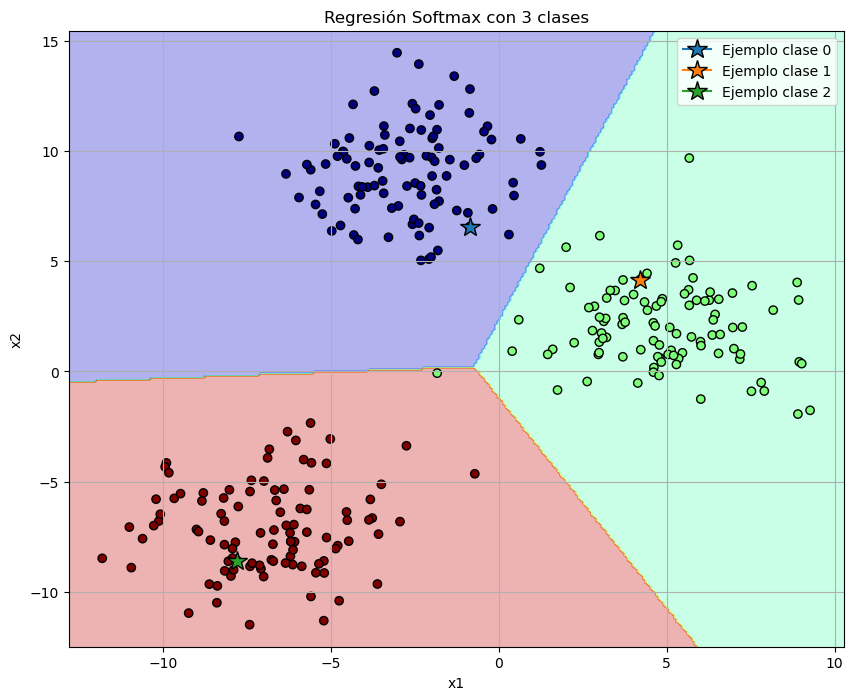


📌 Punto de clase 0: [-0.8641078   6.57259883]
  p_0 = 0.985
  p_1 = 0.015
  p_2 = 0.000
  ✅ Clase predicha: 0

📌 Punto de clase 1: [4.20451643 4.17072339]
  p_0 = 0.002
  p_1 = 0.998
  p_2 = 0.000
  ✅ Clase predicha: 1

📌 Punto de clase 2: [-7.79834899 -8.57979833]
  p_0 = 0.000
  p_1 = 0.000
  p_2 = 1.000
  ✅ Clase predicha: 2


In [50]:
# === Datos para 3 clases ===
X, y = make_blobs(n_samples=300, centers=3, random_state=42, cluster_std=2)
n_classes = len(np.unique(y))
n_features = X.shape[1]

softmax_clf = SoftmaxRegression(n_classes, n_features)
softmax_clf.fit(X, y)

# Un punto por clase
ejemplos = [X[y == i][0] for i in range(n_classes)]

# Visualización
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = softmax_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.jet)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.jet)

for i, punto in enumerate(ejemplos):
    plt.plot(punto[0], punto[1], marker='*', markersize=15,
             markeredgecolor='black', label=f"Ejemplo clase {i}")

plt.title("Regresión Softmax con 3 clases")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Mostrar probabilidades
for i, punto in enumerate(ejemplos):
    print(f"\n📌 Punto de clase {i}: {punto}")
    probs, pred = softmax_clf.predict_proba(punto)
    for k, p in sorted(probs.items()):
        print(f"  {k} = {p:.3f}")
    print(f"  ✅ Clase predicha: {pred}")

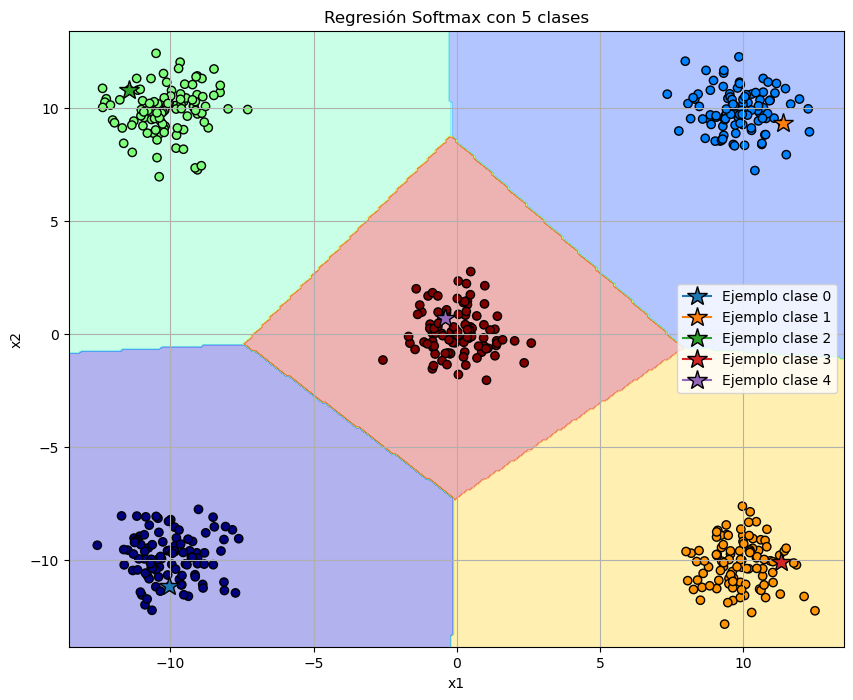


📌 Punto de clase 0: [-10.03928282 -11.1680935 ]
  p_0 = 1.000
  p_1 = 0.000
  p_2 = 0.000
  p_3 = 0.000
  p_4 = 0.000
  ✅ Clase predicha: 0

📌 Punto de clase 1: [11.36453185  9.31055082]
  p_0 = 0.000
  p_1 = 0.999
  p_2 = 0.000
  p_3 = 0.000
  p_4 = 0.001
  ✅ Clase predicha: 1

📌 Punto de clase 2: [-11.4465347   10.80029795]
  p_0 = 0.000
  p_1 = 0.000
  p_2 = 1.000
  p_3 = 0.000
  p_4 = 0.000
  ✅ Clase predicha: 2

📌 Punto de clase 3: [ 11.3277827  -10.10128149]
  p_0 = 0.000
  p_1 = 0.000
  p_2 = 0.000
  p_3 = 1.000
  p_4 = 0.000
  ✅ Clase predicha: 3

📌 Punto de clase 4: [-0.40594173  0.7243685 ]
  p_0 = 0.009
  p_1 = 0.012
  p_2 = 0.019
  p_3 = 0.005
  p_4 = 0.956
  ✅ Clase predicha: 4


In [51]:
# === Versión con 5 clases ===
centros = [[-10, -10], [10, 10], [-10, 10], [10, -10], [0, 0]]
X, y = make_blobs(n_samples=500, centers=centros, cluster_std=1.0, random_state=0)
n_classes = len(np.unique(y))

softmax5 = SoftmaxRegression(n_classes, n_features)
softmax5.fit(X, y)
ejemplos = [X[y == i][0] for i in range(n_classes)]

# Visualización
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
Z = softmax5.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.jet)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.jet)

for i, punto in enumerate(ejemplos):
    plt.plot(punto[0], punto[1], marker='*', markersize=15,
             markeredgecolor='black', label=f"Ejemplo clase {i}")

plt.title("Regresión Softmax con 5 clases")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Mostrar probabilidades
for i, punto in enumerate(ejemplos):
    print(f"\n📌 Punto de clase {i}: {punto}")
    probs, pred = softmax5.predict_proba(punto)
    for k, p in sorted(probs.items()):
        print(f"  {k} = {p:.3f}")
    print(f"  ✅ Clase predicha: {pred}")